<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Local LLM Inference at Scale with vLLM</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

## What we're building, and why this way

Every previous notebook in this series treated the language model as a remote service: a string goes out over HTTPS, a string comes back, and somebody else's GPU does the work. That abstraction is wonderful right up to the moment you need to run the model over **ten thousand documents**, or on data that cannot leave the building, or at a cost that does not scale with the number of tokens. At that point you need to run the model yourself, and running a model yourself *well* is a different skill from calling an API.

[vLLM](https://github.com/vllm-project/vllm) is the open-source inference engine that most self-hosted LLM deployments run on. By the end of this notebook we will have:

1. A **quantitative mental model** of why naive, one-request-at-a-time generation leaves a GPU almost idle, and what vLLM does about it.
2. A **principled model choice** for the machine in front of us. Not "the biggest that fits", but the one that fits *comfortably*, derived from memory bandwidth and parameter counts.
3. The vLLM **offline engine** loaded inside the notebook, with its cold-start cost and memory footprint measured rather than guessed.
4. The three features that matter in practice, each **measured** on real data: *continuous batching*, *prefix caching*, and *structured outputs*.
5. A **structured extraction** over thousands of scientific abstracts from the OpenAlex database we built in notebook 5, turned into an analysis of what "scaling laws" means across fields.
6. The one-line jump from the in-notebook engine to an **OpenAI-compatible server** that the harness from notebooks 3 and 4 can talk to without code changes.

**Why the offline engine and not the server first?** The server is what you deploy. But a server hides every object behind HTTP, and the point of this series is to see the objects. The `LLM` class gives us the same engine, the same scheduler and the same KV cache, with every request's token counts, cache hits and timings in our hands.

**Why this corpus?** The engine shines on *many independent short prompts*, which is exactly what a few thousand abstracts are. And we already know this dataset's blind spots from the EDA in notebook 5, so when the model's output disagrees with OpenAlex's own topic labels we can tell who is likely wrong.

**Why measure?** Inference engines are sold on throughput numbers measured on hardware you do not own. Every performance claim in this notebook is a number we compute in a cell you can re-run.

### Setup

Three groups of imports. The standard library and `sqlite3` reach back into the OpenAlex database from notebook 5. `pydantic` defines the schema that will *constrain* the model's output in Section 8, exactly as it validated tool arguments in notebook 3. And `vllm` itself: the `LLM` engine, `SamplingParams` for the per-request knobs, and `StructuredOutputsParams` for grammar-constrained decoding. `transformers` appears only to read the model's configuration file, so we can do arithmetic on the architecture before loading a single weight.

In [ ]:
import hashlib
import json
import math
import os
import pickle
import sqlite3
import time
from collections import Counter
from pathlib import Path
from typing import Literal
import dataclasses

import numpy as np
import pandas as pd
from pydantic import BaseModel, Field, ValidationError
from tqdm.notebook import tqdm

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, ConnectionPatch


from transformers import AutoConfig
import vllm
from vllm import LLM, SamplingParams
from vllm.sampling_params import StructuredOutputsParams

import watermark

%load_ext watermark
%matplotlib inline

We start by printing out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 6.17.0-1026-nvidia
Machine     : aarch64
Processor   : aarch64
CPU cores   : 20
Architecture: 64bit

Git hash: 30627789668e33417889c74c2a3aa939856a415f

json         : 2.0.9
matplotlib   : 3.10.8
numpy        : 2.4.4
pandas       : 3.0.3
pydantic     : 2.13.2
pydantic_core: 2.46.2
tqdm         : 4.67.3
transformers : 5.17.0
vllm         : 0.31.0
watermark    : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

### Configuration

Everything tunable lives in one cell. A few of these deserve a word:

* `MODEL` is the Hugging Face repository of the model we will justify in Section 1. It is a public, Apache-2.0 checkpoint, so no token or license click-through is needed.
* `MAX_MODEL_LEN` caps the context window the engine *reserves* for each request. The model supports 262k tokens; our abstracts need about 2k. Reserving less lets the engine keep far more requests in flight at once, which is the whole game.
* `GPU_MEMORY_UTILIZATION` is the fraction of device memory vLLM is allowed to claim for weights **plus** KV cache. This machine shares its memory between CPU and GPU, so we leave room for everything else that is running.
* `N_WORKS` is the laptop-feasibility valve for the extraction in Section 8. Two thousand abstracts take a few minutes; the full nine thousand take proportionally longer and change none of the conclusions.
* `CACHE_DIR` is where every generation and measurement is saved, so that re-running the notebook reloads results instead of regenerating them (Section 3 explains how). `REFRESH_CACHE = True` ignores the saved results and produces everything again, for instance to re-measure on different hardware.

In [ ]:
MODEL        = "Qwen/Qwen3.5-35B-A3B-FP8"
MAX_MODEL_LEN = 4096
MAX_ABSTRACT_TOKENS = MAX_MODEL_LEN // 2   # leaves room in every prompt for the instructions and the answer
GPU_MEMORY_UTILIZATION = 0.50
MAX_NUM_SEQS = 256          # upper bound on concurrent requests in one scheduler step
N_WORKS      = 2000
SEED         = 42

DB_PATH = Path("data") / "openalex.db"
OUTPUT_DIR = Path("outputs") / "vllm"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
REFRESH_CACHE = False       # True regenerates every result and overwrites the cache

MEMORY_BANDWIDTH_GBPS = 273.0   # DGX Spark LPDDR5x, from the spec sheet
DEVICE_MEMORY_GB      = 128.0   # unified, shared with the CPU

## 1. Why naive generation wastes a GPU

A decoder-only language model produces text one token at a time. To emit token $t+1$ it must run a forward pass over the whole network with the first $t$ tokens as context. Two facts about that forward pass determine everything about inference performance:

**Fact 1: generating one token reads every weight once.** A 7-billion-parameter model in 16-bit precision is 14 GB of weights, and each decode step streams all 14 GB from memory into the compute units to do a comparatively trivial amount of arithmetic. The step is *memory-bandwidth bound*, not compute bound. A useful first-order model of single-stream decode speed is therefore

$$\text{tokens/s} \;\approx\; \frac{\text{memory bandwidth}}{\text{bytes read per token}}$$

and the GPU's teraflops barely enter the picture.

**Fact 2: the weights are the same for every request.** If we process 64 requests in the same forward pass, we still read the weights once, but produce 64 tokens. Batching is almost free in bandwidth terms, right up to the point where the arithmetic finally becomes the bottleneck. This is why a server handling many users is dramatically more efficient *per token* than a notebook generating one answer at a time.

The catch is the **KV cache**. To avoid recomputing attention over the prefix at every step, each request keeps the keys and values of every previous token resident in GPU memory. That cache grows with the sequence, differs in size for every request, and in a naive implementation must be pre-allocated at the maximum length. That fragmentation is what used to limit batch sizes to a handful of requests.

vLLM's two foundational ideas attack exactly these two problems:

* **PagedAttention** stores the KV cache in fixed-size blocks, like virtual memory pages, so requests of different lengths share the pool with no fragmentation and no up-front reservation.
* **Continuous batching** adds new requests to the running batch and retires finished ones *at every decode step*, instead of waiting for the slowest request in a fixed batch to finish.

Everything else, including prefix caching and constrained decoding, is built on top of these two. Let us turn Fact 1 into a model-selection tool before we load anything.

### Choosing a model for *this* machine

The machine is an NVIDIA DGX Spark: one GB10 Grace Blackwell chip with 128 GB of unified LPDDR5x memory at 273 GB/s. The headline is the memory: it will *hold* almost any open model under 120B parameters. The fine print is the bandwidth, which is about a quarter of a data-center GPU's. By Fact 1, that bandwidth divided by the bytes a model reads per token is the decode speed ceiling for a single request.

Two architectural choices move that number by an order of magnitude:

* **Mixture of Experts (MoE)** models route each token through a small subset of their parameters. A "35B-A3B" model has 35 billion parameters resident in memory but *activates* only 3 billion per token, so it reads roughly a tenth of its weights per step.
* **FP8 quantization** halves the bytes per parameter relative to BF16, with negligible quality loss on current Blackwell hardware, which has native FP8 tensor cores.

The table below applies the formula to the strongest open-weight model families released in 2026 that vLLM supports today. "Comfortable" means: the weights take less than a third of memory (leaving the rest for KV cache and the OS) **and** the single-stream ceiling is above 50 tokens/s, which is faster than anyone reads.

In [5]:
candidates = pd.DataFrame([
    # name,                      total B,  active B,  bytes/param
    ("Qwen3.5-9B (BF16)",             9,        9,       2),
    ("Qwen3.5-27B (BF16)",           27,       27,       2),
    ("Qwen3.5-27B (FP8)",            27,       27,       1),
    ("Qwen3.5-35B-A3B (BF16)",       35,        3,       2),
    ("Qwen3.5-35B-A3B (FP8)",        35,        3,       1),
    ("Gemma 4 31B (BF16)",           31,       31,       2),
    ("Gemma 4 26B-A4B (BF16)",       26,        4,       2),
    ("gpt-oss-20b (MXFP4, 3.6B act)",21,      3.6,     0.6),
    ("Qwen3.5-122B-A10B (FP8)",     122,       10,       1),
], columns=["model", "total_B", "active_B", "bytes_per_param"])

candidates["weights_GB"] = candidates.total_B * candidates.bytes_per_param
candidates["bytes_per_token_GB"] = candidates.active_B * candidates.bytes_per_param
candidates["single_stream_tok_s"] = MEMORY_BANDWIDTH_GBPS / candidates.bytes_per_token_GB
candidates["comfortable"] = (candidates.weights_GB < DEVICE_MEMORY_GB / 3) & (candidates.single_stream_tok_s > 50)

candidates.round(1).sort_values("single_stream_tok_s", ascending=False)

,model,total_B,active_B,bytes_per_param,weights_GB,bytes_per_token_GB,single_stream_tok_s,comfortable
7,"gpt-oss-20b (MXFP4, 3.6B act)",21,3.6,0.6,12.6,2.2,126.4,True
4,Qwen3.5-35B-A3B (FP8),35,3.0,1.0,35.0,3.0,91.0,True
3,Qwen3.5-35B-A3B (BF16),35,3.0,2.0,70.0,6.0,45.5,False
6,Gemma 4 26B-A4B (BF16),26,4.0,2.0,52.0,8.0,34.1,False
8,Qwen3.5-122B-A10B (FP8),122,10.0,1.0,122.0,10.0,27.3,False
0,Qwen3.5-9B (BF16),9,9.0,2.0,18.0,18.0,15.2,False
2,Qwen3.5-27B (FP8),27,27.0,1.0,27.0,27.0,10.1,False
1,Qwen3.5-27B (BF16),27,27.0,2.0,54.0,54.0,5.1,False
5,Gemma 4 31B (BF16),31,31.0,2.0,62.0,62.0,4.4,False


Three things jump out.

1. **Dense 27B-31B models fit but crawl.** At 7-10 tokens/s for a single request they are fine for batch jobs and painful for anything interactive. The fit/comfort distinction is real.
2. **MoE models dominate the decode ceiling.** The 35B-A3B reads about 3 GB per token in FP8, giving a ceiling near 90 tokens/s, a full order of magnitude over its dense sibling of similar quality.
3. **Memory is not the constraint; bandwidth is.** Even the 122B-A10B would fit in 128 GB, and its ceiling is still above the dense 27B's. But it takes 122 GB of weights, leaving nothing for the KV cache, which is where batching lives.

The choice for this tutorial is therefore **Qwen3.5-35B-A3B in FP8**: 37.5 GB of weights, 3B active parameters, Apache-2.0, native vLLM support, and a chat template with a thinking mode we can switch on and off. Gemma 4's 26B-A4B would be the obvious alternative. Note the "FP8" is a different checkpoint, not a load-time flag: the weights were quantized once, offline, by the model's authors, and the engine reads the quantization scheme from the configuration.

### The model: Qwen3.5-35B-A3B

A few words on what we are about to load, because the choice is not only arithmetic.

**What it is.** Qwen3.5 is Alibaba's open-weight model family of early 2026, released under Apache-2.0 with weights on Hugging Face. The flagship is a 397B mixture-of-experts; the 35B-A3B is the mid-sized member of the same architecture, which matters because everything the ecosystem has built for the family, from inference kernels to fine-tuning recipes, applies to it directly. The "35B-A3B" naming is literal: 35 billion parameters resident in memory, about 3 billion *active* per token, routed through 8 of 256 experts in every layer. The checkpoint we use is the FP8 version published by the Qwen team themselves, so there is no third-party quantization step to audit.

**What is unusual about it.** Three design choices, each with a direct consequence in this notebook:

* *Hybrid attention.* Three of every four layers are linear-attention layers (a gated delta-rule recurrence) with a fixed-size state; only every fourth is conventional full attention. This cuts the KV cache per token by 4x (Section 2) and is also what sets an unusually large KV block size, with a consequence we meet head-on in Section 7.
* *Hybrid reasoning.* The model thinks in a `<think>` block before answering, and the chat template exposes a switch to turn that off per request. We use both modes in Section 4 and keep thinking off for bulk extraction, where the answer, not the deliberation, is what we pay for.
* *Native multimodality and long context.* The checkpoint ships a vision tower and a 262,144-token context window. We disable the first and cap the second at 4,096 tokens, which is the difference between a model that *could* read a paper's figures and one that reads two thousand abstracts before lunch.

**Why this one.** The table above makes the quantitative case: 35 GB of weights leaves most of the machine's memory for the KV cache, and 3 GB read per token gives a decode ceiling near 90 tokens/s, an order of magnitude above a dense model of comparable quality. The qualitative case is ecosystem maturity. vLLM supports the architecture natively, ships a reasoning parser for its think blocks, and can use the model's multi-token-prediction head for speculative decoding (Section 11). The repository is public and ungated, so a reader can reproduce this notebook without a license click-through. Gemma 4 26B-A4B would have been the obvious alternative on the arithmetic; gpt-oss-20b is faster still but a weaker model for careful reading of scientific text.


## 2. Anatomy of the model, before loading it

The configuration file is a few kilobytes and tells us everything the arithmetic above needs, plus one important surprise. Qwen3.5 is a **hybrid attention** architecture: only every fourth layer is a conventional full-attention layer with a growing KV cache. The other three are *linear attention* layers (a gated delta-rule recurrence) whose state is a fixed-size matrix per sequence, independent of context length.

This matters directly for inference capacity. The KV cache per token is

$$\text{bytes/token} = 2 \times L_{\text{full}} \times H_{kv} \times d_{\text{head}} \times \text{bytes}$$

where the factor 2 is for keys *and* values, and $L_{\text{full}}$ counts only the full-attention layers. Let us compute it and translate it into "how many abstracts can be in flight at once".

In [6]:
cfg = AutoConfig.from_pretrained(MODEL)
tc = getattr(cfg, "text_config", cfg)          # multimodal checkpoints nest the LM config

layer_types = Counter(tc.layer_types)
n_full = layer_types.get("full_attention", tc.num_hidden_layers)
head_dim = getattr(tc, "head_dim", tc.hidden_size // tc.num_attention_heads)
kv_bytes_per_token = 2 * n_full * tc.num_key_value_heads * head_dim * 2   # BF16 cache

print(f"Architecture        : {cfg.architectures[0]}")
print(f"Layers              : {tc.num_hidden_layers}  ->  {dict(layer_types)}")
print(f"Experts             : {tc.num_experts} total, {tc.num_experts_per_tok} active per token")
print(f"KV heads x head_dim : {tc.num_key_value_heads} x {head_dim}")
print(f"Native context      : {tc.max_position_embeddings:,} tokens")
print()
print(f"KV cache            : {kv_bytes_per_token/1024:.1f} KB per token "
      f"(a dense {tc.num_hidden_layers}-layer model would need "
      f"{kv_bytes_per_token * tc.num_hidden_layers / n_full / 1024:.1f} KB)")

kv_budget_gb = 20
print(f"A {kv_budget_gb} GB KV budget holds ~{kv_budget_gb*2**30/kv_bytes_per_token/1e6:.1f}M tokens, "
      f"or ~{kv_budget_gb*2**30/kv_bytes_per_token/MAX_MODEL_LEN:,.0f} requests at MAX_MODEL_LEN={MAX_MODEL_LEN}")

Architecture        : Qwen3_5MoeForConditionalGeneration
Layers              : 40  ->  {'linear_attention': 30, 'full_attention': 10}
Experts             : 256 total, 8 active per token
KV heads x head_dim : 2 x 256
Native context      : 262,144 tokens

KV cache            : 20.0 KB per token (a dense 40-layer model would need 80.0 KB)
A 20 GB KV budget holds ~1.0M tokens, or ~256 requests at MAX_MODEL_LEN=4096


The hybrid design cuts the per-token cache by 4x compared to a conventional model of the same depth. Twenty gigabytes of cache is room for thousands of concurrent requests at our context length, which means that for this workload the scheduler, not memory, will decide how many requests run together. We cap that with `MAX_NUM_SEQS` to keep the measurements in Section 6 interpretable.

## 3. Starting the engine

Constructing `LLM` does a great deal of work, and it is worth knowing what, because the first start on a machine is slow and people often conclude something is broken:

1. **Load the weights** (37 GB from local disk).
2. **Profile memory**: run a forward pass at the maximum batch shape to measure peak activation memory, then hand *everything else* up to `gpu_memory_utilization` to the KV cache allocator.
3. **Compile** the model's forward pass with `torch.compile`, and **capture CUDA graphs** for a range of batch sizes so that decode steps launch as a single graph instead of hundreds of individual kernels. This is the step that takes minutes the first time and seconds afterwards, because the results are cached on disk.

Two arguments need an explanation. `limit_mm_per_prompt={"image": 0, "video": 0}` tells the engine we will never send images, so it skips loading the vision tower that this multimodal checkpoint ships with. `enable_prefix_caching=True` is the default in current vLLM; we spell it out because Section 7 depends on it. And `reasoning_parser="qwen3"` teaches the engine where this model's `<think>` block starts and ends, which is what lets it enforce a thinking budget in Section 4 and, in Section 8, hold off the output grammar until the model has finished reasoning.

One practical warning. An engine keeps its memory until the Python process that created it exits, and a second engine started in the same kernel will not fit next to the first. Re-running the cell below therefore reuses the engine that is already running; to change an engine argument, restart the kernel.

In [7]:
ENGINE_ARGS = dict(
    model=MODEL,
    max_model_len=MAX_MODEL_LEN,
    max_num_seqs=MAX_NUM_SEQS,
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
    enable_prefix_caching=True,
    limit_mm_per_prompt={"image": 0, "video": 0},
    reasoning_parser="qwen3",
    seed=SEED,
)

if globals().get("running_engine_args") == ENGINE_ARGS:
    print("Reusing the engine already running in this kernel")
elif "llm" in globals():
    raise RuntimeError("An engine is already running in this kernel and holds its share of GPU memory. "
                       "Restart the kernel to start one with new arguments.")
else:
    t0 = time.perf_counter()
    llm = LLM(**ENGINE_ARGS)
    running_engine_args = ENGINE_ARGS
    load_s = time.perf_counter() - t0
    print(f"Engine ready in {load_s/60:.1f} min")

(MainProcess pid=2446176) INFO 10-07 09:58:59 [api_utils.py:286] non-default args: {'seed': 42, 'max_model_len': 4096, 'enable_prefix_caching': True, 'gpu_memory_utilization': 0.5, 'max_num_seqs': 256, 'disable_log_stats': True, 'limit_mm_per_prompt': {'image': 0, 'video': 0}, 'reasoning_parser': 'qwen3', 'model': 'Qwen/Qwen3.5-35B-A3B-FP8'}
(MainProcess pid=2446176) INFO 10-07 09:58:59 [model.py:699] Resolved architecture: Qwen3_5MoeForConditionalGeneration
(MainProcess pid=2446176) INFO 10-07 09:58:59 [model.py:2109] Using max model len 4096
(MainProcess pid=2446176) WARNING 10-07 09:58:59 [model.py:1069] Model does not support mm_device_do_normalize, forcing mm_device_do_normalize = False.
(MainProcess pid=2446176) INFO 10-07 09:59:00 [model.py:917] All limits of multimodal modalities supported by the model are set to 0, running in text-only mode.
(MainProcess pid=2446176) INFO 10-07 09:59:00 [model.py:974] Disabled mm_prefix attention mode because multimodal inputs are configuratio

Loading safetensors checkpoint shards:   0% Completed | 0/14 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:   7% Completed | 1/14 [00:05<01:06,  5.14s/it]
Loading safetensors checkpoint shards:  14% Completed | 2/14 [00:10<01:05,  5.45s/it]
Loading safetensors checkpoint shards:  21% Completed | 3/14 [00:15<00:56,  5.13s/it]
Loading safetensors checkpoint shards:  29% Completed | 4/14 [00:19<00:48,  4.81s/it]
Loading safetensors checkpoint shards:  36% Completed | 5/14 [00:25<00:46,  5.18s/it]
Loading safetensors checkpoint shards:  43% Completed | 6/14 [00:31<00:42,  5.32s/it]
Loading safetensors checkpoint shards:  50% Completed | 7/14 [00:37<00:38,  5.46s/it]
Loading safetensors checkpoint shards:  57% Completed | 8/14 [00:42<00:33,  5.54s/it]
Loading safetensors checkpoint shards:  64% Completed | 9/14 [01:07<00:58, 11.64s/it]
Loading safetensors checkpoint shards:  71% Completed | 10/14 [01:13<00:38,  9.69s/it]
Loading safetensors checkpoint shards:  79% Completed | 11/14

(EngineCore pid=2446386) INFO 10-07 10:00:53 [default_loader.py:484] Loading weights took 102.49 seconds
(EngineCore pid=2446386) INFO 10-07 10:00:53 [deep_gemm.py:197] deep_gemm not found in site-packages, trying vendored vllm.third_party.deep_gemm
(EngineCore pid=2446386) INFO 10-07 10:00:53 [deep_gemm.py:224] DeepGEMM PDL enabled on vllm.third_party.deep_gemm.
(EngineCore pid=2446386) INFO 10-07 10:00:53 [deep_gemm.py:136] DeepGEMM E8M0 enabled on current platform.
(EngineCore pid=2446386) INFO 10-07 10:00:56 [fp8.py:838] Using MoEPrepareAndFinalizeNoDPEPModular
(EngineCore pid=2446386) INFO 10-07 10:01:06 [model_runner.py:407] Model loading took 33.61 GiB memory and 118.781538 seconds
(EngineCore pid=2446386) INFO 10-07 10:01:06 [topk_topp_sampler.py:124] Using FlashInfer for top-p & top-k sampling.
(EngineCore pid=2446386) INFO 10-07 10:01:06 [torch_utils.py:286] Reducing Torch threads from 20 to 1 for serving. Set OMP_NUM_THREADS in the external environment to override.
(EngineCo

Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 13.82it/s]


(EngineCore pid=2446386) INFO 10-07 10:01:41 [model_runner.py:1087] Graph capturing finished in 26 secs, took 1.50 GiB
(EngineCore pid=2446386) INFO 10-07 10:01:41 [gpu_worker.py:692] Available KV cache memory: 23.69 GiB
(EngineCore pid=2446386) INFO 10-07 10:01:41 [gpu_worker.py:707] CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.5000 is equivalent to --gpu-memory-utilization=0.4874 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.5126. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0.
(EngineCore pid=2446386) INFO 10-07 10:01:41 [kv_cache_utils.py:2464] GPU KV cache size: 481,280 tokens, Maximum concurrency for 4,096 tokens per request: 117.50x
(EngineCore pid=2446386) INFO 10-07 10:01:47 [kernel_warmup.py:172] JIT kernel warmup starting.
(EngineCore pid=2446386) INFO 10-07 10:01:47 [kernel_warmup.py:185] JIT kernel warmup finished in 0.

...

(EngineCore pid=2446386) INFO 10-07 10:01:48 [kernel_warmup.py:437] Using FlashInfer autotune cache file: /home/bgoncalves/.cache/vllm/flashinfer_autotune_cache/0.7.0.post1/121a/6ef12a628b5d7d5b042af578a7e748f746cc578983a8c9f4b8d444d31ecc47ef/autotune_configs.json


2026-10-07 10:01:48,885 - INFO - autotuner.py:3691 - flashinfer.jit: [Autotuner]: Loaded 0 configs from /home/bgoncalves/.cache/vllm/flashinfer_autotune_cache/0.7.0.post1/121a/6ef12a628b5d7d5b042af578a7e748f746cc578983a8c9f4b8d444d31ecc47ef/autotune_configs.json
2026-10-07 10:01:48,887 - INFO - autotuner.py:1046 - flashinfer.jit: [Autotuner]: Autotuning process starts ...


(EngineCore pid=2446386) INFO 10-07 10:01:48 [kernel_warmup.py:359] Running FlashInfer autotune with 8192 tokens and token buckets (1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 768, 1024, 1280, 1536, 1792, 2048, 2560, 3072, 3584, 4096, 8192).


2026-10-07 10:01:50,760 - INFO - autotuner.py:1069 - flashinfer.jit: [Autotuner]: Autotuning process ends
2026-10-07 10:01:50,764 - INFO - autotuner.py:3554 - flashinfer.jit: [Autotuner]: Saved 0 configs to /home/bgoncalves/.cache/vllm/flashinfer_autotune_cache/0.7.0.post1/121a/6ef12a628b5d7d5b042af578a7e748f746cc578983a8c9f4b8d444d31ecc47ef/autotune_configs.json (0 new, 0 from previous config)
Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:02<00:00, 15.64it/s]


(EngineCore pid=2446386) INFO 10-07 10:02:20 [model_runner.py:1087] Graph capturing finished in 28 secs, took 0.74 GiB
(EngineCore pid=2446386) INFO 10-07 10:02:20 [gpu_worker.py:892] CUDA graph pool memory: 0.74 GiB (actual), 1.54 GiB (estimated), difference: 0.8 GiB (108.9%).
(EngineCore pid=2446386) INFO 10-07 10:02:20 [gpu_worker.py:955] Free memory on device (69.83/121.69 GiB) on startup. Desired GPU memory utilization is (0.5, 60.84 GiB). Actual usage is 35.16 GiB for consumed memory (weights + non-torch), 2.0 GiB for peak activation, and 0.74 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=24485588480` (22.8 GiB) to fit into requested memory, or `--kv-cache-memory=34128154112` (31.78 GiB) to fully utilize gpu memory. Current kv cache memory in use is 23.69 GiB.
(EngineCore pid=2446386) INFO 10-07 10:02:21 [jit_monitor.py:84] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=244638

Scroll through the log the engine printed. The lines worth finding are the one reporting how many **GPU KV cache blocks** were allocated (multiply by the block size to get tokens), the one announcing the **maximum concurrency** the cache supports at `max_model_len`, and the timing of **graph capturing**. If a future run is mysteriously slower, these are the first numbers to compare.

### Where the memory went

The llama.cpp post ended with a picture of a 16 GB Mac's memory with a 1B model in it. Here is the same picture for this machine and this model, drawn from the numbers the engine just printed. The values are typed in from the log rather than queried, because the engine reports them once, at startup, and they are the ones to record.

Three things to read off it. The weights and the KV cache are roughly the same size: vLLM takes everything up to `gpu_memory_utilization` that the weights and activations do not need and hands it to the cache, so the budget knob is really a *cache size* knob. The OS, the notebook kernel and the editor hold about 14 GiB on their own, and on a unified-memory machine that is exactly why the knob matters: there is no separate VRAM, so whatever the engine reserves comes out of the same pool everything else runs in. (When this was measured, Ollama also happened to have a 37 GiB model loaded; it is left out of the picture because it is not part of this setup, and it is also why the budget was set at 0.5 rather than higher.) And the 28.8 GiB cache holds 585k tokens, about 52 KB per token rather than the 20 KB computed in Section 2: the linear-attention layers' recurrent state is paged in the same pool as the attention cache, and it is not free either.


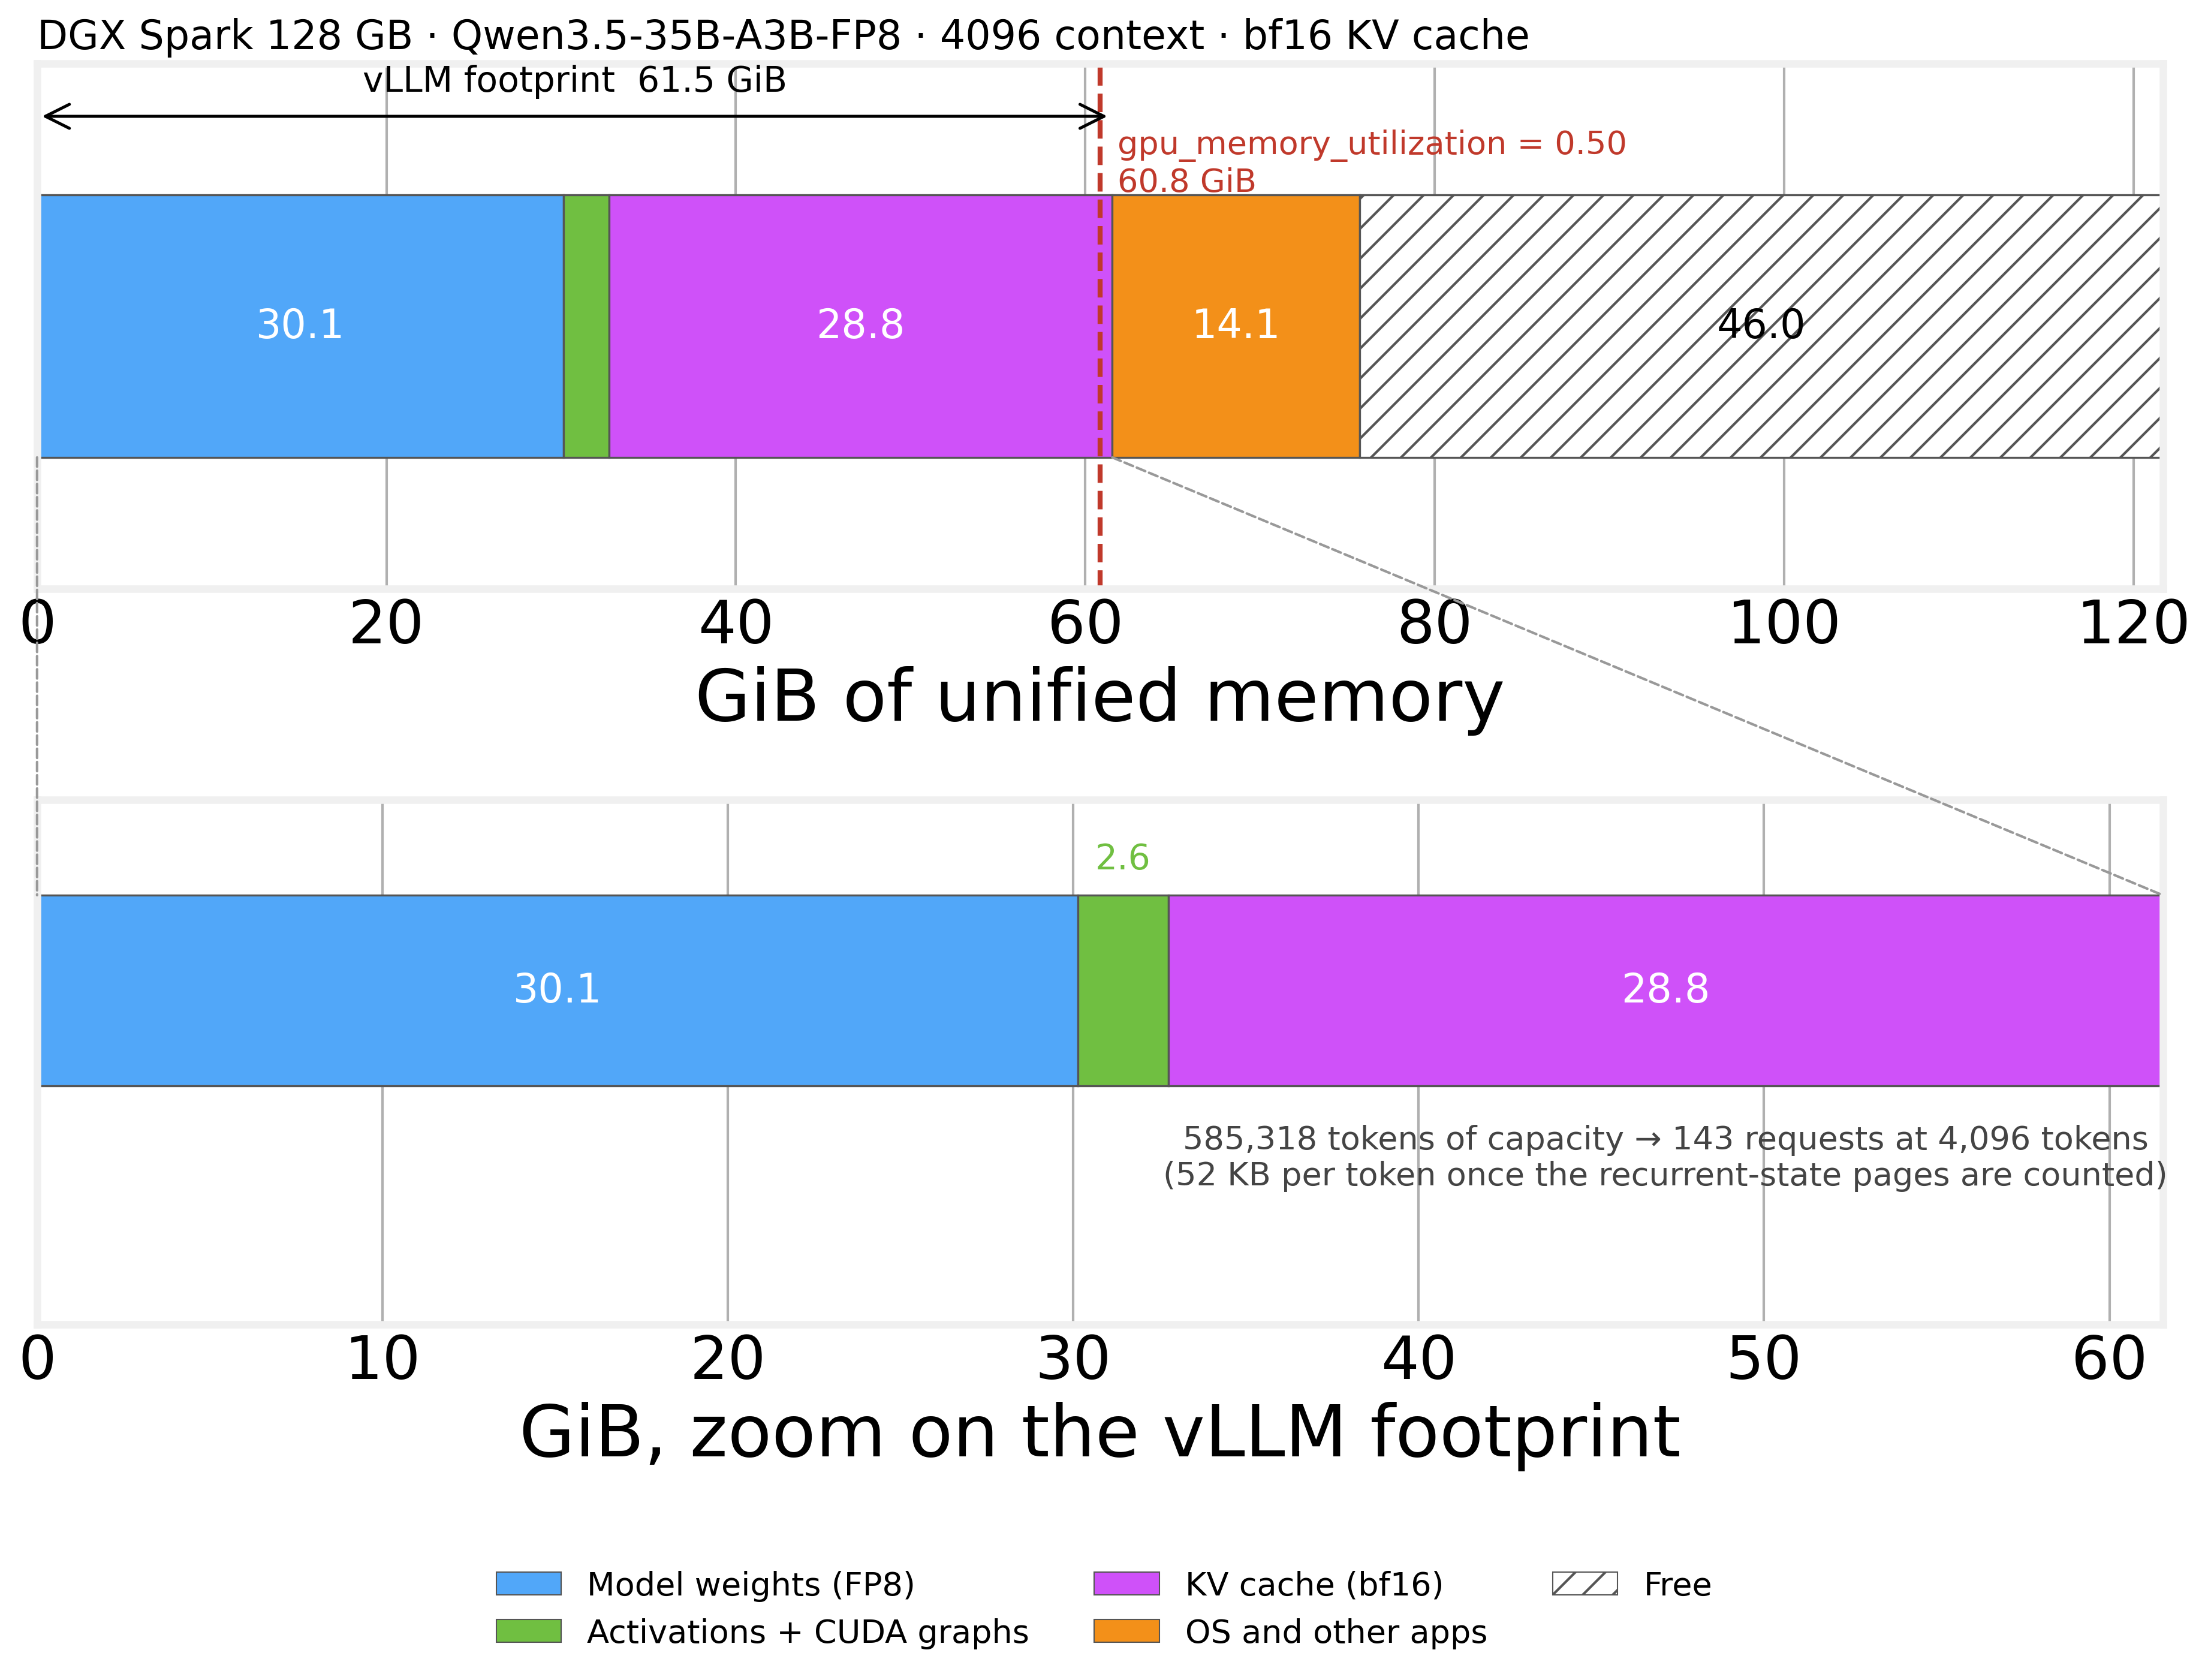

In [ ]:
# --- from the engine log above (GiB) ---
memory = dict(
    total         = 121.69,   # "Free memory on device (70.44/121.69 GiB) on startup"
    free_at_start = 70.44,
    weights       = 30.13,    # "30.13 GiB for consumed memory (weights + non-torch)"
    activations   = 1.92,     # "1.92 GiB for peak activation"
    cuda_graphs   = 0.70,     # "0.7 GiB for CUDAGraph memory"
    kv_cache      = 28.8,     # "Available KV cache memory: 28.8 GiB"
)
kv_tokens      = 585_318      # "GPU KV cache size: 585,318 tokens"
max_concurrent = 142.9        # "Maximum concurrency for 4,096 tokens per request: 142.90x"
ollama_gpu     = 37.1         # nvidia-smi: a model Ollama happened to have loaded; not part of this setup

other_apps = memory["total"] - memory["free_at_start"] - ollama_gpu   # OS, notebook kernel, editor
engine = memory["weights"] + memory["activations"] + memory["cuda_graphs"] + memory["kv_cache"]
free = memory["total"] - other_apps - engine
budget = GPU_MEMORY_UTILIZATION * memory["total"]

segments = [  # (label, GiB, colour, hatch)
    ("Model weights (FP8)",       memory["weights"],                             colors[0], None),
    ("Activations + CUDA graphs", memory["activations"] + memory["cuda_graphs"], colors[2], None),
    ("KV cache (bf16)",           memory["kv_cache"],                            colors[1], None),
    ("OS and other apps",         other_apps,                                    colors[3], None),
    ("Free",                      free,                                          "white",   "//"),
]

def draw_bar(ax, segs, xmax, label_min):
    left, edges = 0, []
    for label, size, color, hatch in segs:
        ax.barh(0, size, left=left, color=color, hatch=hatch, edgecolor="#555555", linewidth=0.8, height=0.6)
        if size >= label_min:
            ax.text(left + size / 2, 0, f"{size:.1f}", ha="center", va="center", fontsize=16,
                    color="white" if color != "white" else "black")
        edges.append((left, left + size))
        left += size
    ax.set_xlim(0, xmax); ax.set_ylim(-0.6, 0.6); ax.set_yticks([]); ax.grid(axis="y", visible=False)
    return edges

fig, (ax_top, ax_bot) = plt.subplots(2, 1, gridspec_kw={"height_ratios": [1, 1]})
fig.subplots_adjust(hspace=0.9)

edges = draw_bar(ax_top, segments, memory["total"], label_min=5)
ax_top.axvline(budget, color="#c0392b", linestyle="--", linewidth=2)
ax_top.text(budget + 1, 0.45, f"gpu_memory_utilization = {GPU_MEMORY_UTILIZATION:.2f}\n{budget:.1f} GiB",
            color="#c0392b", fontsize=13, va="top")
ax_top.annotate("", xy=(0, 0.48), xytext=(engine, 0.48), arrowprops=dict(arrowstyle="<->", color="black", lw=1.2))
ax_top.text(engine / 2, 0.52, f"vLLM footprint  {engine:.1f} GiB", ha="center", va="bottom", fontsize=14)
ax_top.set_xlabel("GiB of unified memory")
ax_top.set_title(f"DGX Spark 128 GB · {MODEL.split('/')[-1]} · {MAX_MODEL_LEN} context · bf16 KV cache",
                 fontsize=16, loc="left")

zedges = draw_bar(ax_bot, segments[:3], engine, label_min=3)
ax_bot.set_ylim(-1.05, 0.6)
ax_bot.set_xlabel("GiB, zoom on the vLLM footprint")
ax_bot.text(sum(zedges[1]) / 2, 0.36, f"{zedges[1][1] - zedges[1][0]:.1f}", ha="center", va="bottom",
            fontsize=14, color=colors[2])
ax_bot.text(zedges[2][0] + memory["kv_cache"] / 2, -0.42,
            f"{kv_tokens:,} tokens of capacity → {max_concurrent:.0f} requests at {MAX_MODEL_LEN:,} tokens\n"
            f"({memory['kv_cache']*2**30/kv_tokens/1024:.0f} KB per token once the recurrent-state pages are counted)",
            ha="center", va="top", fontsize=13, color="#444444")

for x, zx in [(0, 0), (engine, engine)]:          # dashed guides from the footprint to its zoom
    fig.add_artist(ConnectionPatch(xyA=(x, -0.3), coordsA=ax_top.transData, xyB=(zx, 0.3), coordsB=ax_bot.transData,
                                   color="#999999", linestyle="--", linewidth=1))

handles = [Patch(facecolor=c, edgecolor="#555555", hatch=h, label=l) for l, _, c, h in segments]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=13, frameon=False, bbox_to_anchor=(0.5, -0.09))

### Caching what the engine produces

From here on, every cell that calls the engine goes through the small `cached` helper below. It hashes the vLLM version and the engine arguments together with everything that determines a result, namely the conversations and the public fields of the `SamplingParams`, and pickles the result to `CACHE_DIR` under that hash. (Public fields only, because the engine fills in private ones such as the end-of-sequence token id the first time an object is used, which would otherwise give the same request a different key before and after its first run.) Re-running the notebook reloads each result in a fraction of a second instead of regenerating it, and changing a prompt, a sampling knob or an engine argument produces a new hash, so a stale result is never reused.

Two consequences are worth stating. For the timing experiments of Sections 6 and 7 the cached object is the table of measurements, so a reloaded cell reports the numbers measured by the run that created the cache. And the hash covers a cell's *inputs*, not its code: if you change how a measurement is taken, set `REFRESH_CACHE = True`, or delete the file the cell reports loading, to take it again.

In [ ]:
def _stable(obj):
    """A representation of obj that does not change when the engine annotates it.

    vLLM fills private fields of SamplingParams (eos token ids, compiled grammar handles) the
    first time a request runs, so repr() of the same object differs before and after use.
    Keying on public fields only keeps the cache key the same across runs.
    """
    if hasattr(obj, "__struct_fields__"):              # msgspec Struct, e.g. SamplingParams
        return {f: _stable(getattr(obj, f)) for f in obj.__struct_fields__ if not f.startswith("_")}
    if dataclasses.is_dataclass(obj) and not isinstance(obj, type):
        return {f.name: _stable(getattr(obj, f.name)) for f in dataclasses.fields(obj) if not f.name.startswith("_")}
    if isinstance(obj, dict):
        return {k: _stable(v) for k, v in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_stable(v) for v in obj]
    if hasattr(obj, "__dict__") and not isinstance(obj, type):
        return {k: _stable(v) for k, v in sorted(vars(obj).items()) if not k.startswith("_")}
    return repr(obj)


def cached(name, inputs, compute):
    """Return compute(), or reload the result an earlier run saved for the same engine and inputs."""
    key = hashlib.sha256(repr(_stable((vllm.__version__, ENGINE_ARGS, inputs))).encode()).hexdigest()[:12]
    path = CACHE_DIR / f"{name}__{key}.pkl"
    if path.exists() and not REFRESH_CACHE:
        print(f"Loading cached {name} from {path}")
        with open(path, "rb") as f:
            return pickle.load(f)
    result = compute()
    tmp = path.with_suffix(".tmp")      # an interrupted dump must never look like a valid cache file
    with open(tmp, "wb") as f:
        pickle.dump(result, f)
    tmp.replace(path)
    print(f"Cached {name} to {path}")
    return result


## 4. A first request

vLLM's `LLM.chat` takes the same `messages` list the Anthropic and OpenAI SDKs do and applies the model's own **chat template** to turn it into the token sequence the model was trained on. `SamplingParams` carries the per-request knobs. We set the ones that matter:

* `temperature`, `top_p` and `top_k` follow the model authors' recommended values for non-thinking mode.
* `max_tokens` is a hard stop; without it the default is a stingy 16.
* `seed` makes the run reproducible *per request*, which is what makes the measurements later in this notebook comparable.

Qwen3.5 is a **hybrid reasoning** model: by default it thinks before answering, in a `<think>...</think>` block. For bulk extraction we want the answer, not the deliberation, so we pass `enable_thinking=False` through `chat_template_kwargs`. The template then pre-fills an empty think block, and the model goes straight to the answer.

In [10]:
NO_THINK = {"enable_thinking": False}

sampling = SamplingParams(temperature=0.7, top_p=0.8, top_k=20, max_tokens=256, seed=SEED)

messages = [
    {"role": "system", "content": "You are a concise scientific assistant."},
    {"role": "user", "content": "In two sentences, what is a scaling law, and why do physicists and "
                                "machine learning researchers both care about them?"},
]

out = cached("first_request", (messages, sampling, NO_THINK),
             lambda: llm.chat(messages, sampling, chat_template_kwargs=NO_THINK, use_tqdm=False)[0])
print(out.outputs[0].text)

Loading cached first_request from outputs/vllm/cache/first_request__4b3e0f88ec01.pkl
A scaling law is an empirical relationship that describes how a system's performance or behavior changes predictably as its size or resources increase. Both physicists and machine learning researchers care about them because they reveal universal principles governing complex systems, allowing scientists to extrapolate future performance from limited data and optimize resource allocation for massive models or physical experiments.


The return value is a `RequestOutput`, and it is worth looking inside, because these fields are the raw material for every measurement that follows. In particular `num_cached_tokens` reports how many prompt tokens were served from the prefix cache rather than computed, and `metrics` carries the timestamps the scheduler recorded for the request.

In [11]:
completion = out.outputs[0]
print(f"prompt tokens     : {len(out.prompt_token_ids)}")
print(f"cached tokens     : {out.num_cached_tokens}")
print(f"generated tokens  : {len(completion.token_ids)}")
print(f"finish reason     : {completion.finish_reason}")
if out.metrics is not None:
    m = out.metrics
    print(f"time to first tok : {m.first_token_latency*1000:.0f} ms")
    print(f"decode time       : {m.last_token_ts - m.first_token_ts:.2f} s "
          f"-> {(len(completion.token_ids)-1)/(m.last_token_ts - m.first_token_ts):.1f} tok/s single stream")

prompt tokens     : 47
cached tokens     : 0
generated tokens  : 66
finish reason     : stop


### Thinking mode, briefly

Switching thinking on changes the output shape: the model emits its reasoning, closes it with `</think>`, then answers. The reasoning tokens are real generated tokens that you pay for in time, so for anything with a fixed schema and a clear answer we keep it off. `thinking_token_budget` puts a ceiling on how long the model may deliberate.

In [12]:
THINK = {"enable_thinking": True}

think_sampling = SamplingParams(temperature=0.6, top_p=0.95, top_k=20, max_tokens=1500, seed=SEED,
                                thinking_token_budget=800)
out_think = cached("thinking", (messages, think_sampling, THINK),
                   lambda: llm.chat(messages, think_sampling, chat_template_kwargs=THINK, use_tqdm=False)[0])

text = out_think.outputs[0].text
reasoning, _, answer = text.partition("</think>")
print(f"reasoning: {len(reasoning.split())} words   |   answer: {len(answer.split())} words   "
      f"|   total generated tokens: {len(out_think.outputs[0].token_ids)}")
print()
print("REASONING (first 600 chars):", reasoning.strip()[:600], "...", sep="\n")
print()
print("ANSWER:", answer.strip(), sep="\n")

Loading cached thinking from outputs/vllm/cache/thinking__3bebda61b773.pkl
reasoning: 520 words   |   answer: 43 words   |   total generated tokens: 854

REASONING (first 600 chars):
Thinking Process:

1.  **Analyze the Request:**
    *   Task: Define a scaling law and explain why both physicists and machine learning researchers care about them.
    *   Constraint: Exactly two sentences.
    *   Tone: Concise scientific assistant.

2.  **Define "Scaling Law":**
    *   General concept: A relationship between two or more variables where one changes as a power of the other (often $y = ax^b$).
    *   Contexts: Physics (e.g., critical phenomena, allometry) and ML (e.g., performance vs. compute/data/parameters).
    *   Draft definition: A scaling law describes a power-law rel
...

ANSWER:
A scaling law describes a power-law relationship where a system's property changes predictably as its size or complexity increases. Physicists and machine learning researchers both rely on these laws to 

## 5. The corpus: scaling-laws abstracts from OpenAlex

Notebook 5 left us a SQLite database of about 11,700 articles whose title or abstract mentions "scaling laws", with OpenAlex's own topic classification attached. We pull every work that has a usable abstract together with its *primary* topic, then take a fixed random sample of `N_WORKS` so that the runs in this notebook are both fast and reproducible.

Note the `is_primary = 1` filter: as Section 3.4 of notebook 5 showed, a work has several topics and joining without the filter silently multiplies rows.

In [13]:
QUERY = """
SELECT w.id, w.title, w.publication_year AS year, w.cited_by_count, w.abstract,
       t.display_name AS topic, t.field, t.domain
FROM works w
JOIN work_topics wt ON wt.work_id = w.id AND wt.is_primary = 1
JOIN topics t       ON t.id = wt.topic_id
WHERE w.abstract IS NOT NULL AND length(w.abstract) > 200
"""
with sqlite3.connect(DB_PATH) as conn:
    corpus = pd.read_sql(QUERY, conn)

works = corpus.sample(N_WORKS, random_state=SEED).reset_index(drop=True)
print(f"{len(corpus):,} works with abstracts; sampled {len(works):,}")
works[["title", "year", "domain", "field"]].head()

9,144 works with abstracts; sampled 2,000


,title,year,domain,field
0,A general scenario of tunneling time in differ...,2022,Physical Sciences,Physics and Astronomy
1,Experiment and modelling of texture and slidin...,2024,Life Sciences,Neuroscience
2,Two-Timescale Design for Simultaneous Transmit...,2024,Physical Sciences,Engineering
3,Hydrology without dimensions,2022,Physical Sciences,Environmental Science
4,"Precessing spherical shells: flows, dissipatio...",2019,Life Sciences,"Biochemistry, Genetics and Molecular Biology"


Prompt length is the unit the engine budgets in, so let us look at it in tokens rather than characters. The tokenizer is the one the engine loaded; using any other would give slightly different counts.

The distribution has a long right tail. A real abstract is a few hundred tokens, but a handful of OpenAlex records carry the paper's full text (or, in one case, a Nobel lecture) in the abstract field, running to several thousand tokens. The engine does not silently truncate a prompt that exceeds `MAX_MODEL_LEN`: it rejects the whole batch. So we drop anything longer than `MAX_ABSTRACT_TOKENS` here, which leaves room for the longest instructions and the answer in every prompt that follows.

dropping 18 works longer than 2048 tokens (longest: 5,337)
total abstract tokens in sample: 590,120


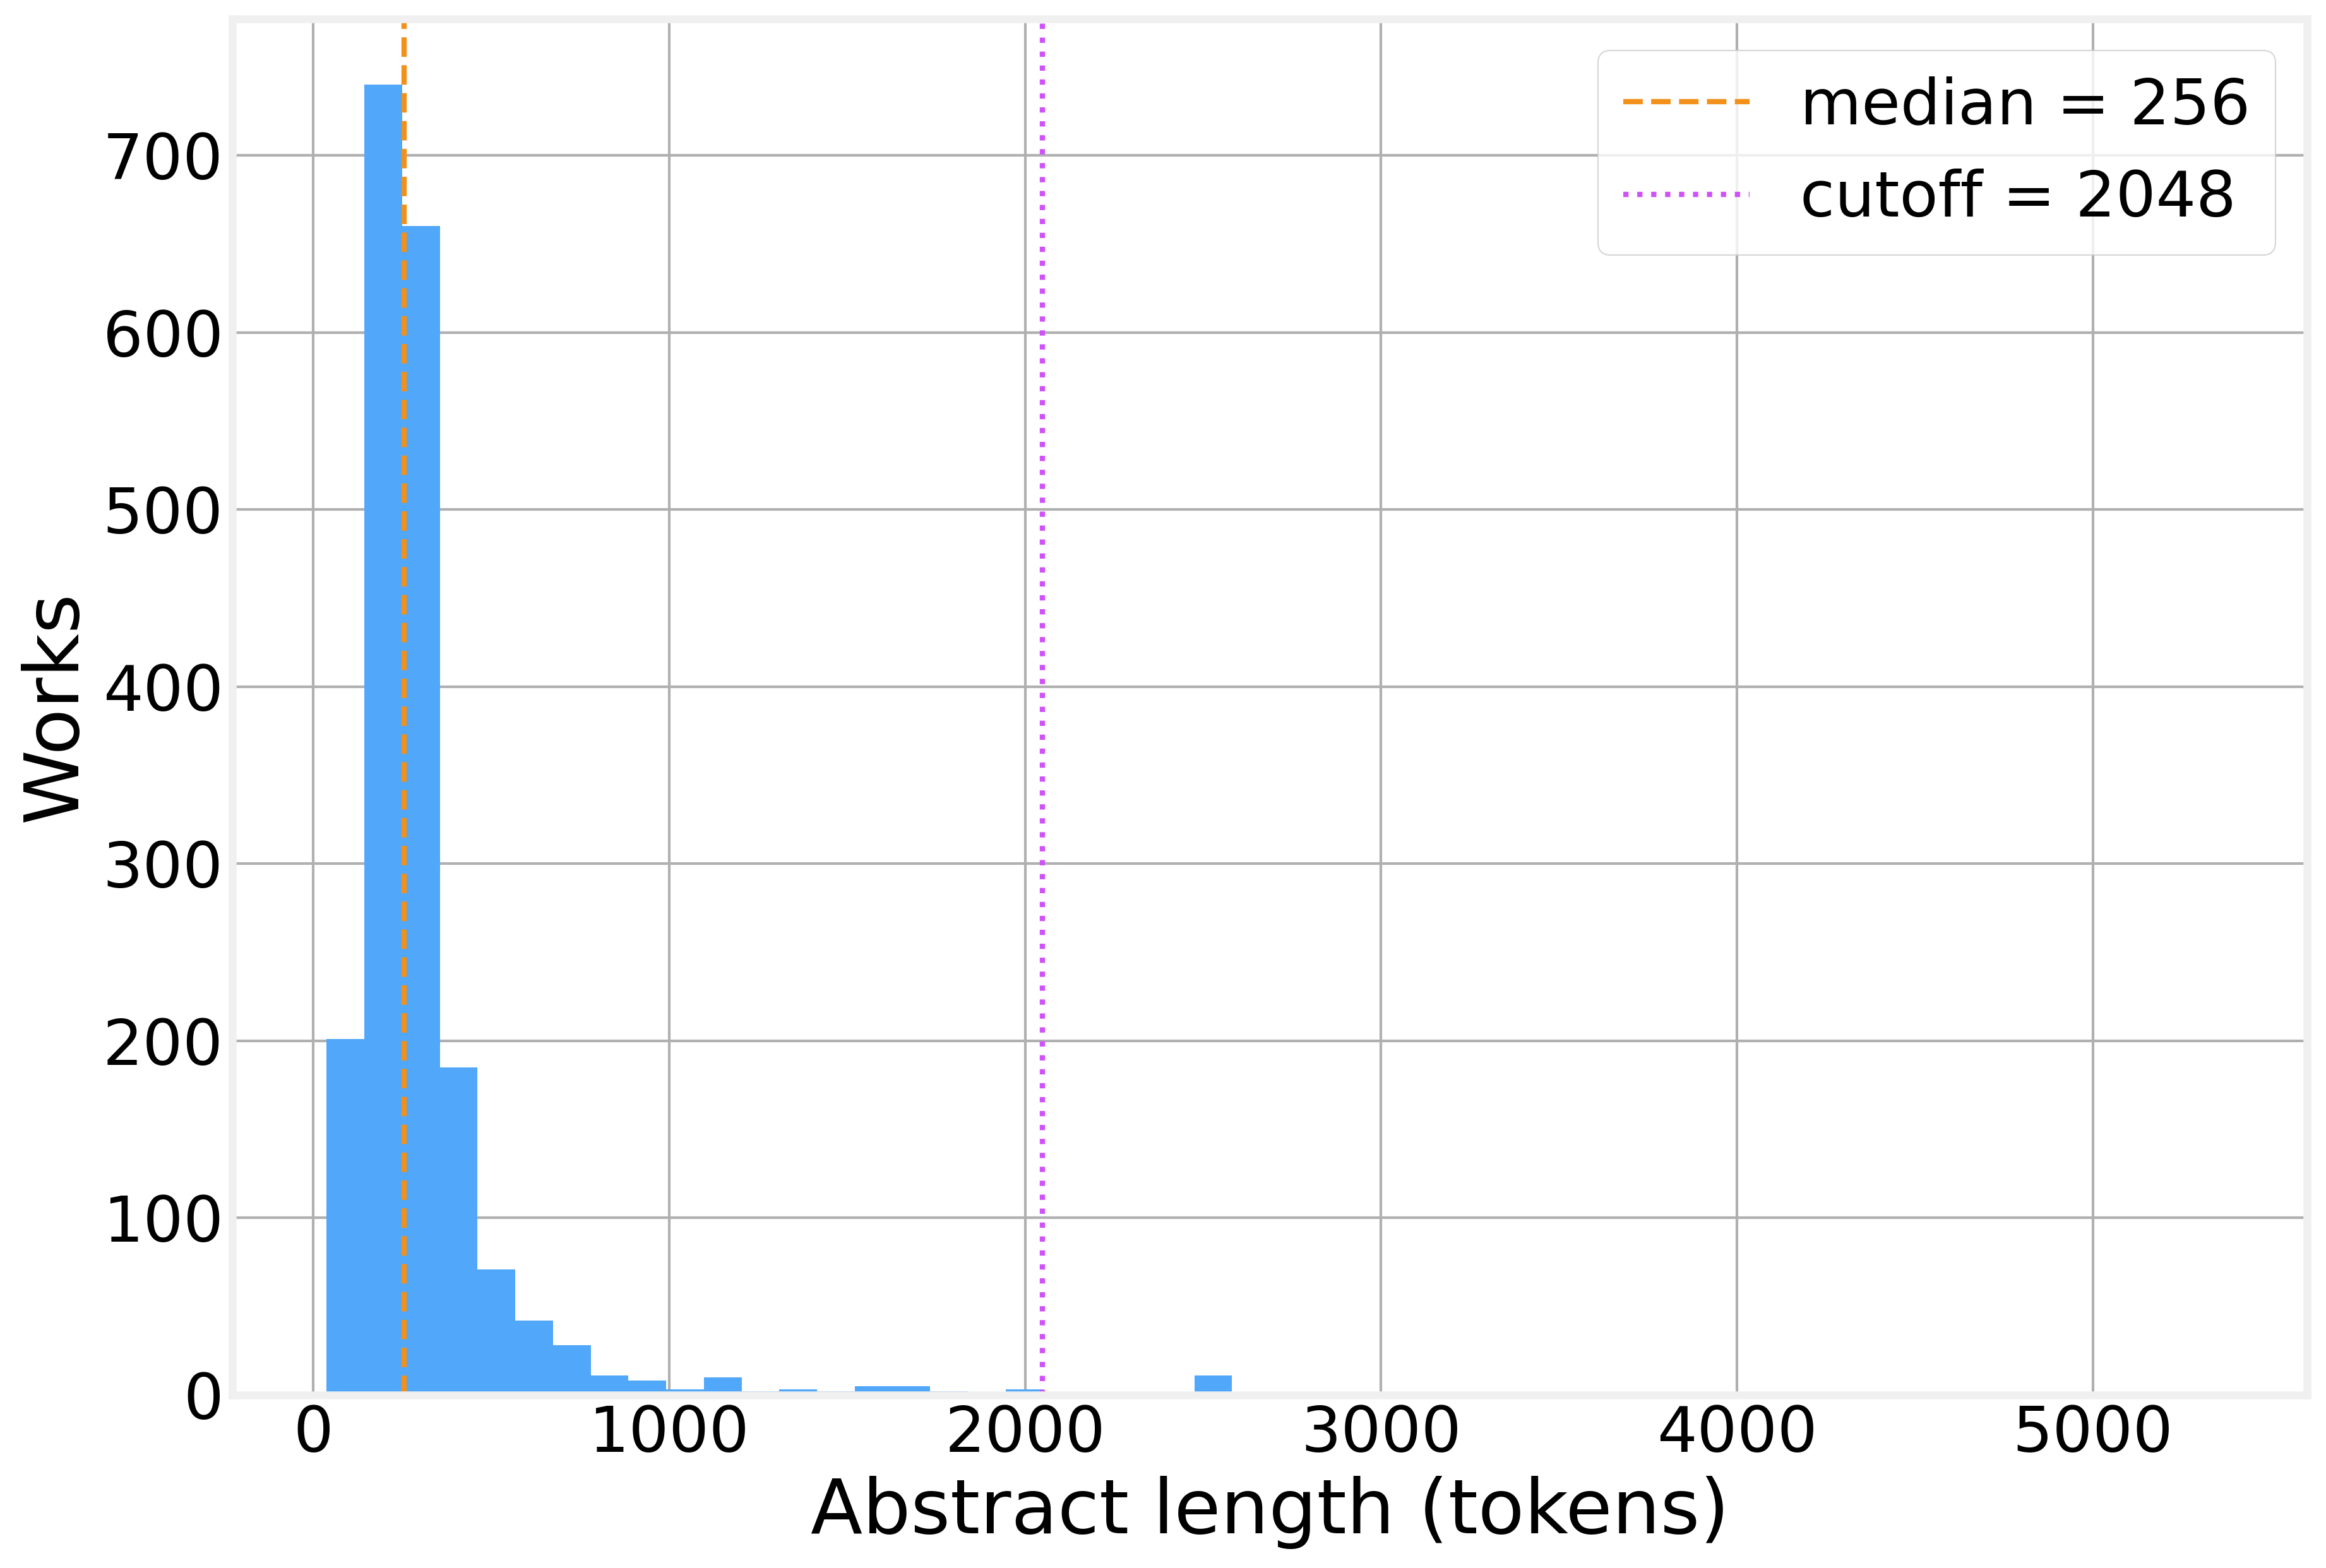

In [ ]:
tokenizer = llm.get_tokenizer()
works["abstract_tokens"] = [len(tokenizer.encode(a)) for a in works.abstract]

fig, ax = plt.subplots()
ax.hist(works.abstract_tokens, bins=50, color=colors[0])
ax.axvline(works.abstract_tokens.median(), color=colors[3], linestyle="--", linewidth=2,
           label=f"median = {works.abstract_tokens.median():.0f}")
ax.axvline(MAX_ABSTRACT_TOKENS, color=colors[1], linestyle=":", linewidth=2,
           label=f"cutoff = {MAX_ABSTRACT_TOKENS}")
ax.set_xlabel("Abstract length (tokens)")
ax.set_ylabel("Works")
ax.legend()

too_long = works.abstract_tokens > MAX_ABSTRACT_TOKENS
print(f"dropping {too_long.sum()} works longer than {MAX_ABSTRACT_TOKENS} tokens "
      f"(longest: {works.abstract_tokens.max():,})")
works = works[~too_long].reset_index(drop=True)
print(f"total abstract tokens in sample: {works.abstract_tokens.sum():,}")

## 6. Continuous batching, measured

The task for this section is deliberately simple so that output length is roughly constant: *in one sentence, say what quantity scales with what in this paper*. We then send the **same requests** in batches of growing size and record the wall-clock time and the number of generated tokens.

Section 1 predicted that throughput should rise almost linearly with batch size until the arithmetic saturates. Here is where we find out whether the prediction survives contact with real hardware.

In [15]:
SUMMARY_SYSTEM = ("You read scientific abstracts. Answer in exactly one sentence of at most 30 words: "
                  "what quantity scales with what in this paper? If the paper is not about a scaling "
                  "relationship, say so.")

def summary_messages(row):
    return [
        {"role": "system", "content": SUMMARY_SYSTEM},
        {"role": "user", "content": f"Title: {row.title}\n\nAbstract: {row.abstract}"},
    ]

summary_sampling = SamplingParams(temperature=0.0, max_tokens=60, seed=SEED)


def run_batch(conversations, sampling, progress=False):
    """Run a list of conversations as one engine call; return (outputs, seconds, generated tokens)."""
    t0 = time.perf_counter()
    outs = llm.chat(conversations, sampling, chat_template_kwargs=NO_THINK, use_tqdm=tqdm if progress else False)
    elapsed = time.perf_counter() - t0
    n_gen = sum(len(o.outputs[0].token_ids) for o in outs)
    return outs, elapsed, n_gen


def cached_batch(name, conversations, sampling):
    """run_batch, reloaded from disk if these conversations were already run with this sampling."""
    return cached(name, (conversations, sampling, NO_THINK),
                  lambda: run_batch(conversations, sampling, progress=True))


BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
bench_convs = [summary_messages(r) for r in works.iloc[:max(BATCH_SIZES)].itertuples()]

def measure_batching():
    bench = []
    for batch_size in tqdm(BATCH_SIZES, desc="Batch sizes"):
        convs = bench_convs[:batch_size]
        repeats = 8 if batch_size == 1 else 1              # average the noisiest point
        total_s, total_gen = 0.0, 0
        for _ in range(repeats):
            _, s, g = run_batch(convs, summary_sampling)
            total_s += s; total_gen += g
        bench.append({"batch_size": batch_size, "seconds": total_s / repeats,
                      "gen_tokens": total_gen / repeats,
                      "tok_per_s": total_gen / total_s})
    return pd.DataFrame(bench)

bench = cached("batching", (bench_convs, summary_sampling, BATCH_SIZES), measure_batching)
for r in bench.itertuples():
    print(f"batch {r.batch_size:4d}: {r.seconds:6.2f} s  {r.gen_tokens:7.0f} tokens  {r.tok_per_s:8.1f} tok/s")

Loading cached batching from outputs/vllm/cache/batching__23bb600c02bb.pkl
batch    1:   0.74 s       25 tokens      33.9 tok/s
batch    2:   0.87 s       40 tokens      45.8 tok/s
batch    4:   1.27 s       86 tokens      67.9 tok/s
batch    8:   1.94 s      189 tokens      97.5 tok/s
batch   16:   3.17 s      394 tokens     124.2 tok/s
batch   32:   4.87 s      764 tokens     156.8 tok/s
batch   64:   7.92 s     1556 tokens     196.4 tok/s
batch  128:  12.77 s     3141 tokens     245.9 tok/s
batch  256:  22.21 s     6309 tokens     284.1 tok/s


speed-up from batch 1 to batch 256: 8x


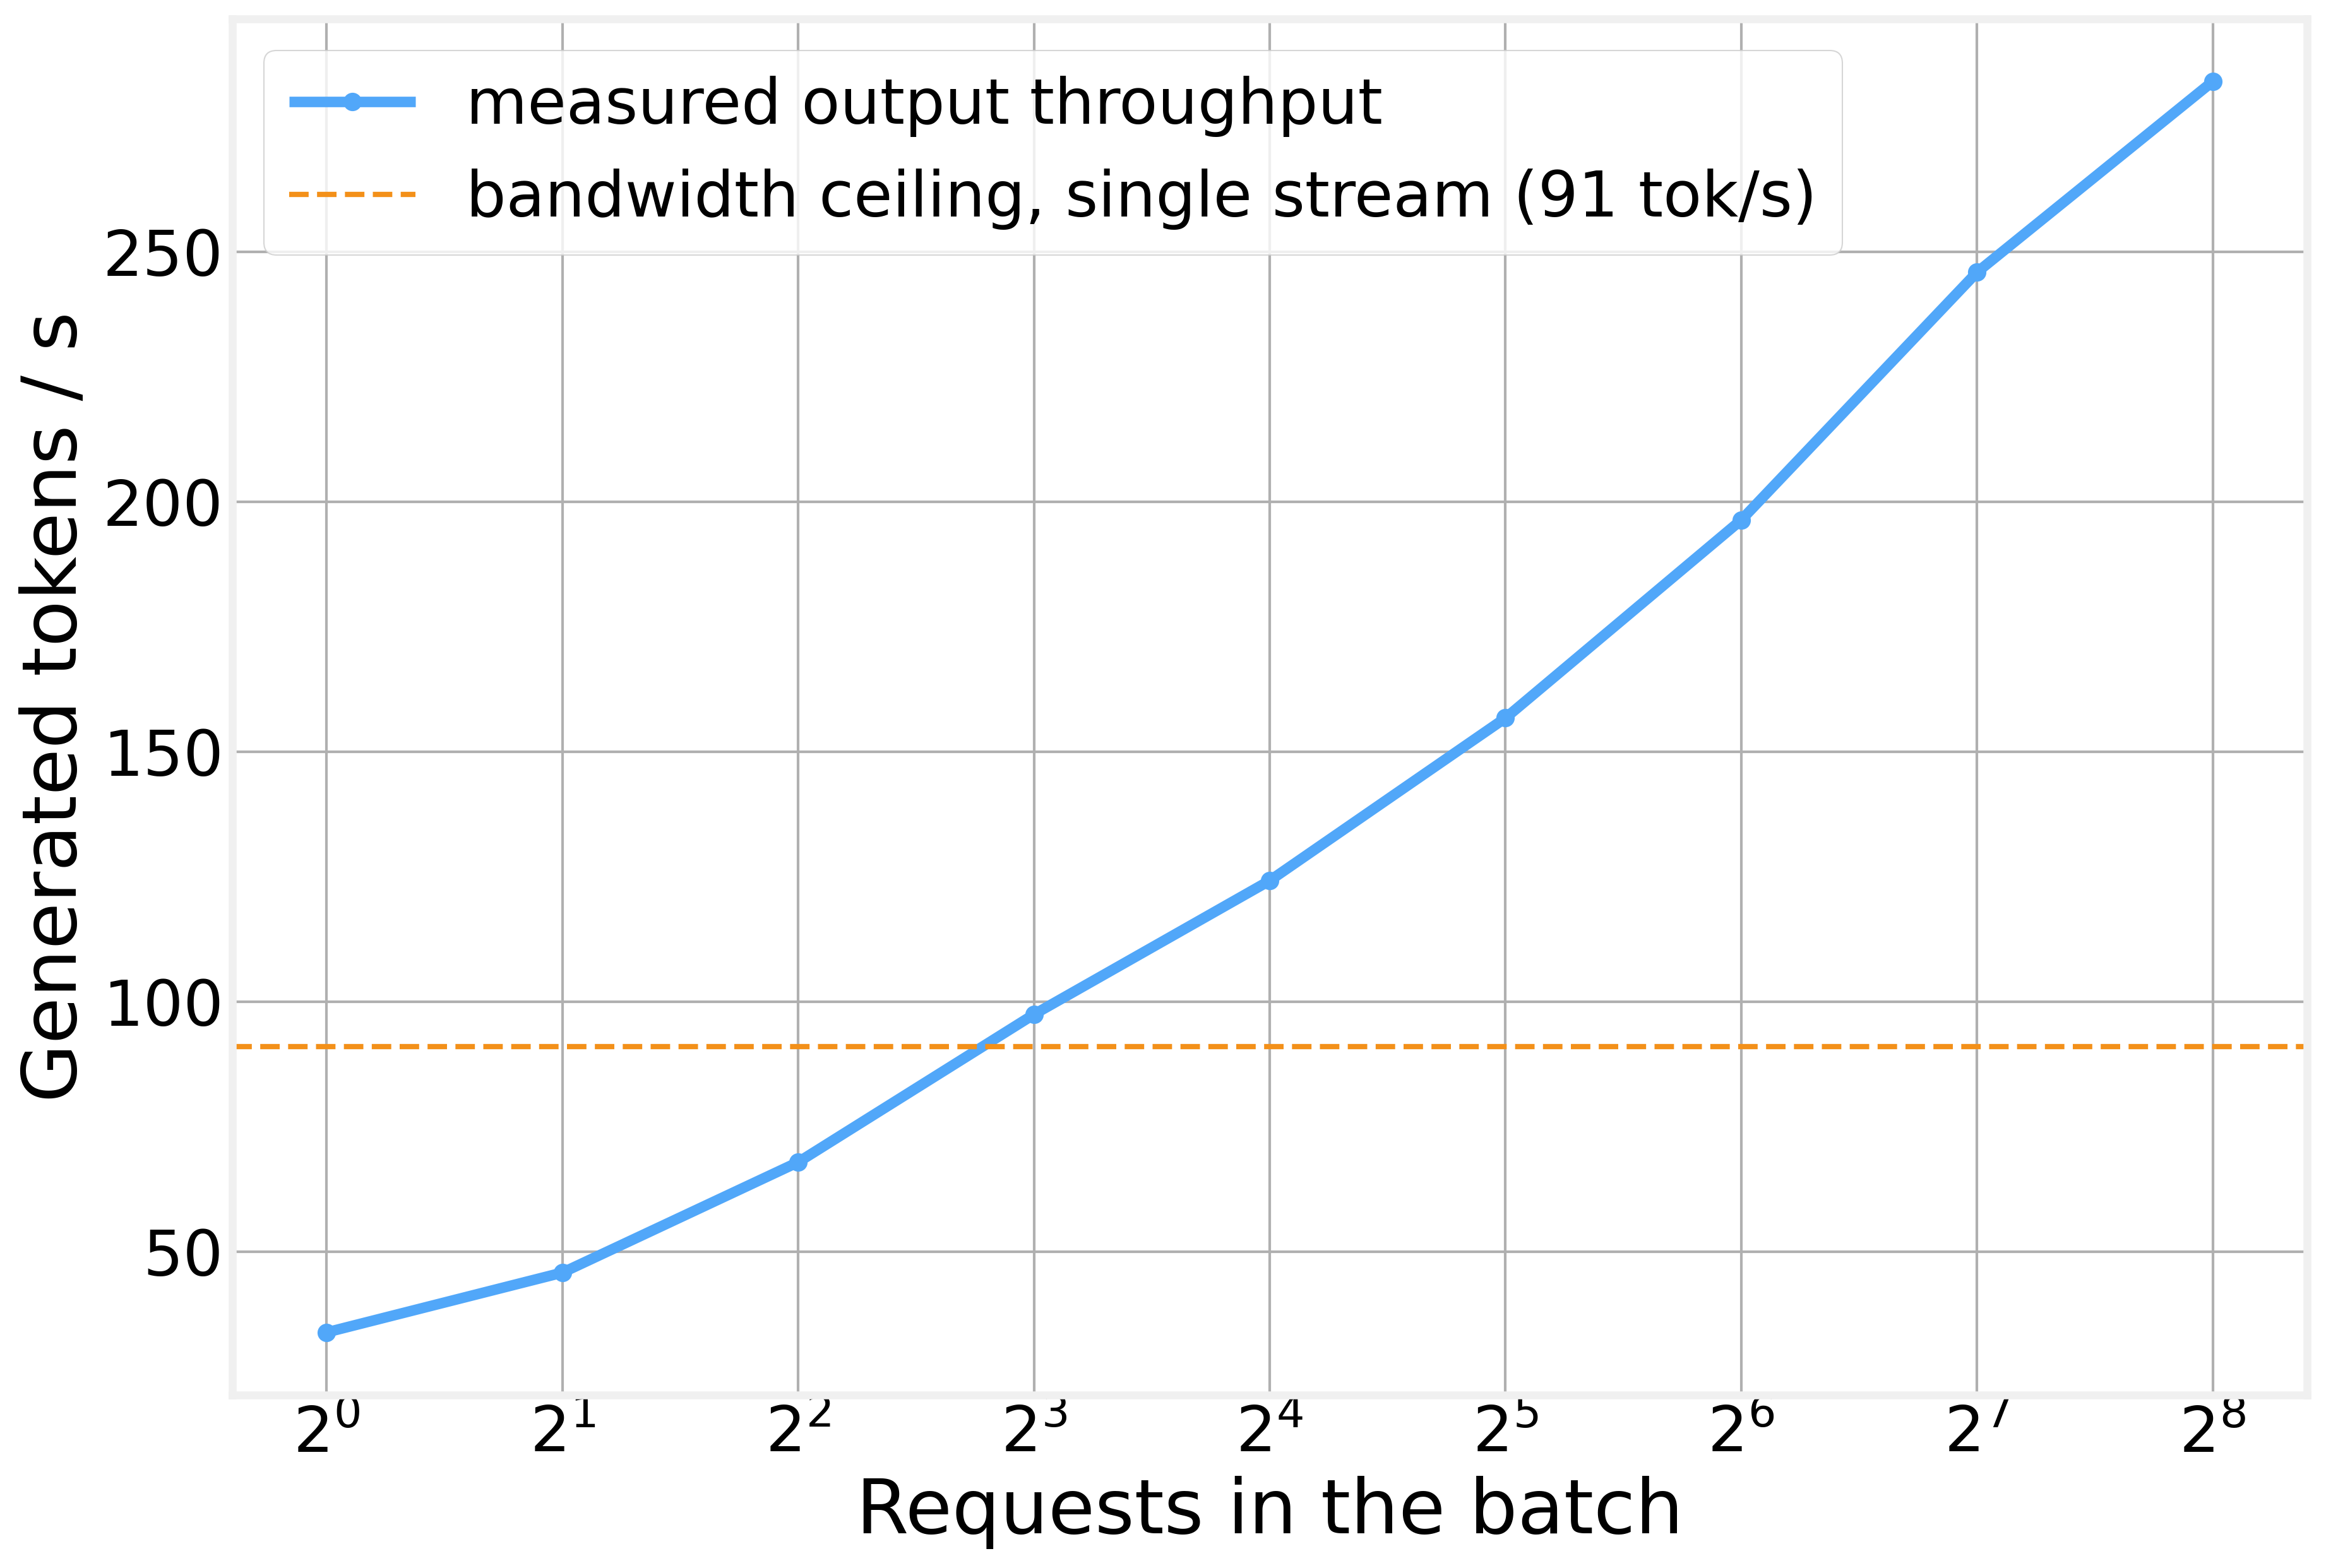

In [ ]:
fig, ax = plt.subplots()
ax.plot(bench.batch_size, bench.tok_per_s, marker="o", color=colors[0], label="measured output throughput")
single = candidates.loc[candidates.model == "Qwen3.5-35B-A3B (FP8)", "single_stream_tok_s"].item()
ax.axhline(single, color=colors[3], linestyle="--", linewidth=2,
           label=f"bandwidth ceiling, single stream ({single:.0f} tok/s)")
ax.set_xscale("log", base=2)
ax.set_xlabel("Requests in the batch")
ax.set_ylabel("Generated tokens / s")
ax.legend()

print(f"speed-up from batch 1 to batch {bench.batch_size.max()}: "
      f"{bench.tok_per_s.iloc[-1] / bench.tok_per_s.iloc[0]:.0f}x")

The curve has the shape Fact 1 and Fact 2 predict. A single request runs at about 34 tokens/s, well below the 91 tokens/s bandwidth ceiling, because the recurrent layers and expert routing are not free. But each additional request in the batch is nearly free: 256 requests finish in about 22 s where one takes 0.7 s, and output throughput reaches roughly 284 tokens/s, an 8x gain on the same model and the same hardware. The curve is smooth all the way up, and it is worth saying that an earlier run of this same sweep was not: it had a dip at 64 that turned out to be a Triton kernel compiling just-in-time for that batch shape, a one-off cost that disappeared once the compiled kernel was cached. The first run of any shape is not the one to time.

Note what this says about **cost**: at the largest batch the GPU produces tokens eight times faster than in the one-at-a-time loop every tutorial starts with, with no change to the model.

This is also the case for running extractions *in bulk* rather than inside an agent loop one tool call at a time, which is a design lesson for the harnesses of notebooks 3 and 4: whenever a step can be formulated as "do this to all of them", do it as one batch.

## 7. Prefix caching, measured

Every request in Section 6 began with the same system prompt. Because the model is causal, the key/value tensors for those shared tokens are *identical* in every request, and PagedAttention's block structure lets the engine notice and reuse them: this is **automatic prefix caching**.

The word *block* carries a condition that is easy to miss. The cache is reused one complete block at a time, so a shared prefix shorter than one block is never shared. For a conventional model a block is 16 tokens and the condition is moot. For this model the engine log in Section 3 says `Setting attention block size to 1056 tokens to ensure that attention page size is >= mamba page size`: the linear-attention layers keep a fixed-size state per sequence, the paged cache has to use units at least that large, and 1,056 tokens is the result.

So we run the experiment with **two prefixes**. A *short* one of about 430 tokens: instructions, three worked examples and a paragraph of background, a perfectly reasonable system prompt that happens to be shorter than one block. And a *long* one of about 1,200 tokens: seven rules, field definitions, ten worked examples and a page of background, which is what a production extraction prompt looks like anyway. The cell prints each prefix's length next to the engine's block size. For each prefix, the same 256 requests run three times:

1. **Cold**, immediately after `reset_prefix_cache()`, so that the first request in the batch has to compute the prefix.
2. **Warm**, again, so that every request finds the prefix already resident.
3. **Cold again**, as a control.

The per-request field `num_cached_tokens` tells us exactly what was reused. The expectation, stated before looking: with the short prefix nothing should be shared at all; with the long one the warm run should serve every complete prefix block from cache, and even the cold run should mostly hit, since within one batch the first scheduled request computes the prefix and the rest should find it.


In [17]:
FEW_SHOT = [
    ("A study of 2,000 cities finds that total road length grows as the 0.85 power of population.",
     "Road length scales sublinearly with city population (exponent 0.85)."),
    ("We train transformers from 10M to 10B parameters and observe test loss decreasing as a power law in compute.",
     "Test loss scales as a power law with training compute across model sizes."),
    ("Metabolic rate measured across 500 mammal species follows Kleiber's three-quarter power law of body mass.",
     "Metabolic rate scales with body mass to the 3/4 power."),
    ("Using 40 years of catalogue data we confirm that earthquake frequency falls off as a power law of magnitude "
     "with a Gutenberg-Richter b-value close to one.",
     "Earthquake frequency scales as a power law with magnitude (b-value near 1)."),
    ("The yield stress of nanocrystalline copper increases with the inverse square root of grain size down to "
     "20 nm, below which the Hall-Petch relation breaks down.",
     "Yield stress scales with the inverse square root of grain size until 20 nm, where the relation breaks down."),
    ("Crystallisation kinetics of the alloy were characterised by differential scanning calorimetry at five heating rates.",
     "No scaling relationship is the main subject."),
    ("River basin drainage area and main-stem length obey Hack's law with an exponent of 0.57 across 300 catchments.",
     "Main-stem river length scales with drainage area to the 0.57 power."),
    ("Patent output per capita in 350 metropolitan areas rises superlinearly with population, with an exponent of 1.25.",
     "Patents per capita scale superlinearly with city population (exponent 1.25)."),
    ("The correlation length diverges near the critical temperature with a critical exponent nu of 0.63 in the "
     "three-dimensional Ising model.",
     "Correlation length scales with distance from the critical temperature as a power law with exponent 0.63."),
    ("Turbulent energy spectra measured in the wind tunnel follow the Kolmogorov -5/3 law over two decades of wavenumber.",
     "Turbulent energy spectrum scales with wavenumber to the -5/3 power."),
]

LONG_SYSTEM = (
    "You are an expert reader of scientific literature on scaling relationships across all fields: "
    "physics, biology, urban science, economics, earth science, engineering, computer science and machine learning.\n\n"
    "Your job is to state, in one sentence of at most 30 words, what quantity scales with what in the "
    "paper. Prefer the paper's own variable names. Mention the exponent if the abstract states one. "
    "If the paper is not primarily about a scaling relationship, reply with exactly: "
    "'No scaling relationship is the main subject.'\n\n"
    "Rules:\n"
    "1. One sentence. No preamble, no bullet points, no quotation marks.\n"
    "2. Do not speculate beyond the abstract. If the exponent is not stated, do not invent one.\n"
    "3. Use plain words for mathematical relations: 'power law', 'linear', 'sublinear', 'superlinear', "
    "'exponential', 'logarithmic'.\n"
    "4. Never mention the authors, the journal, the year or the institution.\n"
    "5. Name the dependent quantity first and the independent variable second.\n"
    "6. If several relationships are reported, state the one the abstract presents as its main result.\n"
    "7. Treat 'scaling' used in the sense of 'scaling up a system' or 'scaling a method to larger inputs' "
    "as not a scaling relationship unless a functional dependence is measured or derived.\n\n"
    "Definitions you should apply:\n"
    "- Dependent quantity: the measured or predicted output (loss, metabolic rate, road length, yield stress).\n"
    "- Independent variable: what it is measured against (compute, body mass, population, grain size).\n"
    "- Exponent: the power k in y proportional to x^k; report it as the abstract states it, including sign.\n"
    "- Sublinear: k below 1 (economies of scale). Superlinear: k above 1 (increasing returns). "
    "Linear: k equal to 1. Allometric: a power law between two body or system measurements.\n\n"
    "Worked examples:\n" +
    "\n".join(f"Abstract: {a}\nAnswer: {b}\n" for a, b in FEW_SHOT) +
    "\n" + "Background on scaling laws, for reference:\n"
    "A scaling law is a functional relationship, typically a power law y = c x^k, between two measurable "
    "quantities that holds over several orders of magnitude. In physics they arise from dimensional analysis, "
    "self-similarity and renormalisation, and the exponents near a phase transition are universal across "
    "materials that share a symmetry class. In biology they arise from network constraints on resource "
    "distribution, the classic case being Kleiber's law relating metabolic rate to body mass with exponent 3/4. "
    "In cities they arise from social and infrastructural interaction networks: infrastructure scales "
    "sublinearly with population while socio-economic outputs scale superlinearly, with exponents near 0.85 "
    "and 1.15. In geomorphology and hydrology they describe how channel length, basin area and discharge "
    "relate to one another. In materials science they relate strength, conductivity or fracture toughness "
    "to microstructural length scales such as grain size or porosity. In turbulence they describe how energy "
    "is distributed across scales. In machine learning they are the empirical regularity that model loss "
    "decreases predictably as a power law in parameters, data and compute, which is used to plan training "
    "runs before they are made. Exponents are diagnostic: sublinear exponents indicate economies of scale, "
    "superlinear ones indicate increasing returns, and a change in exponent usually marks a change in the "
    "dominant mechanism. Not every paper that says 'scaling' has a scaling law: many use the word to mean "
    "running a method on larger inputs, and your answer for those is the fixed sentence above."
)


SHORT_SYSTEM = (
    "You are an expert reader of scientific literature on scaling relationships across all fields: "
    "physics, biology, urban science, economics, computer science and machine learning.\n\n"
    "Your job is to state, in one sentence of at most 30 words, what quantity scales with what in the "
    "paper. Prefer the paper's own variable names. Mention the exponent if the abstract states one. "
    "If the paper is not primarily about a scaling relationship, reply with exactly: "
    "'No scaling relationship is the main subject.'\n\n"
    "Rules:\n"
    "1. One sentence. No preamble, no bullet points, no quotation marks.\n"
    "2. Do not speculate beyond the abstract.\n"
    "3. Use plain words for mathematical relations: 'power law', 'linear', 'sublinear', 'exponential'.\n"
    "4. Never mention the authors, the journal or the year.\n\n"
    "Worked examples:\n" +
    "\n".join(f"Abstract: {a}\nAnswer: {b}\n" for a, b in FEW_SHOT[:3]) +
    "\n" + "Background on scaling laws, for reference: " +
    "A scaling law is a functional relationship, typically a power law y = c x^k, between two measurable "
    "quantities that holds over several orders of magnitude. In physics they arise from dimensional analysis "
    "and renormalization; in biology from network constraints on resource distribution; in cities from "
    "social and infrastructural interaction networks; in machine learning from the empirical regularity "
    "that model loss decreases predictably with parameters, data and compute. Exponents are diagnostic: "
    "sublinear exponents indicate economies of scale, superlinear ones indicate increasing returns. "
)

PREFIXES = {"short": SHORT_SYSTEM, "long": LONG_SYSTEM}

try:
    block_size = llm.llm_engine.vllm_config.cache_config.block_size
except AttributeError:
    block_size = None
prefix_tokens = {}
for name, system in PREFIXES.items():
    prefix_tokens[name] = len(tokenizer.encode(system))
    print(f"{name:5s} prefix: {prefix_tokens[name]:5d} tokens; KV block: {block_size} tokens"
          + (f" -> {prefix_tokens[name] // block_size} complete block(s) shareable" if block_size else ""))

PC_N = 256
def prefix_messages(system, row):
    return [{"role": "system", "content": system},
            {"role": "user", "content": f"Abstract: {row.abstract}\nAnswer:"}]

pc_convs = {name: [prefix_messages(system, r) for r in works.iloc[:PC_N].itertuples()]
            for name, system in PREFIXES.items()}


def measure_prefix_caching(convs):
    """Three runs over the same batch; returns the summary table and per-request cached tokens."""
    runs, per_request = [], {}
    for label in tqdm(["cold", "warm", "cold again"], desc="Prefix-cache runs"):
        if label.startswith("cold"):
            llm.reset_prefix_cache()
        outs, elapsed, n_gen = run_batch(convs, summary_sampling)
        prompt_tok = sum(len(o.prompt_token_ids) for o in outs)
        cached_tok = sum(o.num_cached_tokens or 0 for o in outs)
        per_request[label] = [o.num_cached_tokens or 0 for o in outs]
        runs.append({"run": label, "seconds": elapsed, "prompt_tokens": prompt_tok,
                     "cached_tokens": cached_tok, "cache_hit_rate": cached_tok / prompt_tok,
                     "requests_with_zero_cache": sum(c == 0 for c in per_request[label])})
    return {"runs": pd.DataFrame(runs), "per_request": per_request}


cache_results = {}
for name, convs in PREFIXES.items():
    cache_results[name] = cached(f"prefix_caching_{name}", (pc_convs[name], summary_sampling),
                                 lambda convs=pc_convs[name]: measure_prefix_caching(convs))
    print(f"\n{name} prefix ({prefix_tokens[name]} tokens):")
    for r in cache_results[name]["runs"].itertuples():
        print(f"  {r.run:11s}: {r.seconds:5.2f} s   prompt tokens {r.prompt_tokens:,}   "
              f"from cache {r.cached_tokens:,} ({r.cache_hit_rate:.0%})   "
              f"requests with no cache hit: {r.requests_with_zero_cache}")


short prefix:   428 tokens; KV block: 1056 tokens -> 0 complete block(s) shareable
long  prefix:  1235 tokens; KV block: 1056 tokens -> 1 complete block(s) shareable
Loading cached prefix_caching_short from outputs/vllm/cache/prefix_caching_short__85a61ee25f41.pkl

short prefix (428 tokens):
  cold       : 32.53 s   prompt tokens 182,555   from cache 0 (0%)   requests with no cache hit: 256
  warm       : 30.73 s   prompt tokens 182,555   from cache 8,448 (5%)   requests with no cache hit: 248
  cold again : 31.99 s   prompt tokens 182,555   from cache 0 (0%)   requests with no cache hit: 256
Loading cached prefix_caching_long from outputs/vllm/cache/prefix_caching_long__b7db469ec66d.pkl

long prefix (1235 tokens):
  cold       : 24.51 s   prompt tokens 389,403   from cache 269,280 (69%)   requests with no cache hit: 1
  warm       : 24.04 s   prompt tokens 389,403   from cache 273,504 (70%)   requests with no cache hit: 0
  cold again : 24.50 s   prompt tokens 389,403   from cache 269

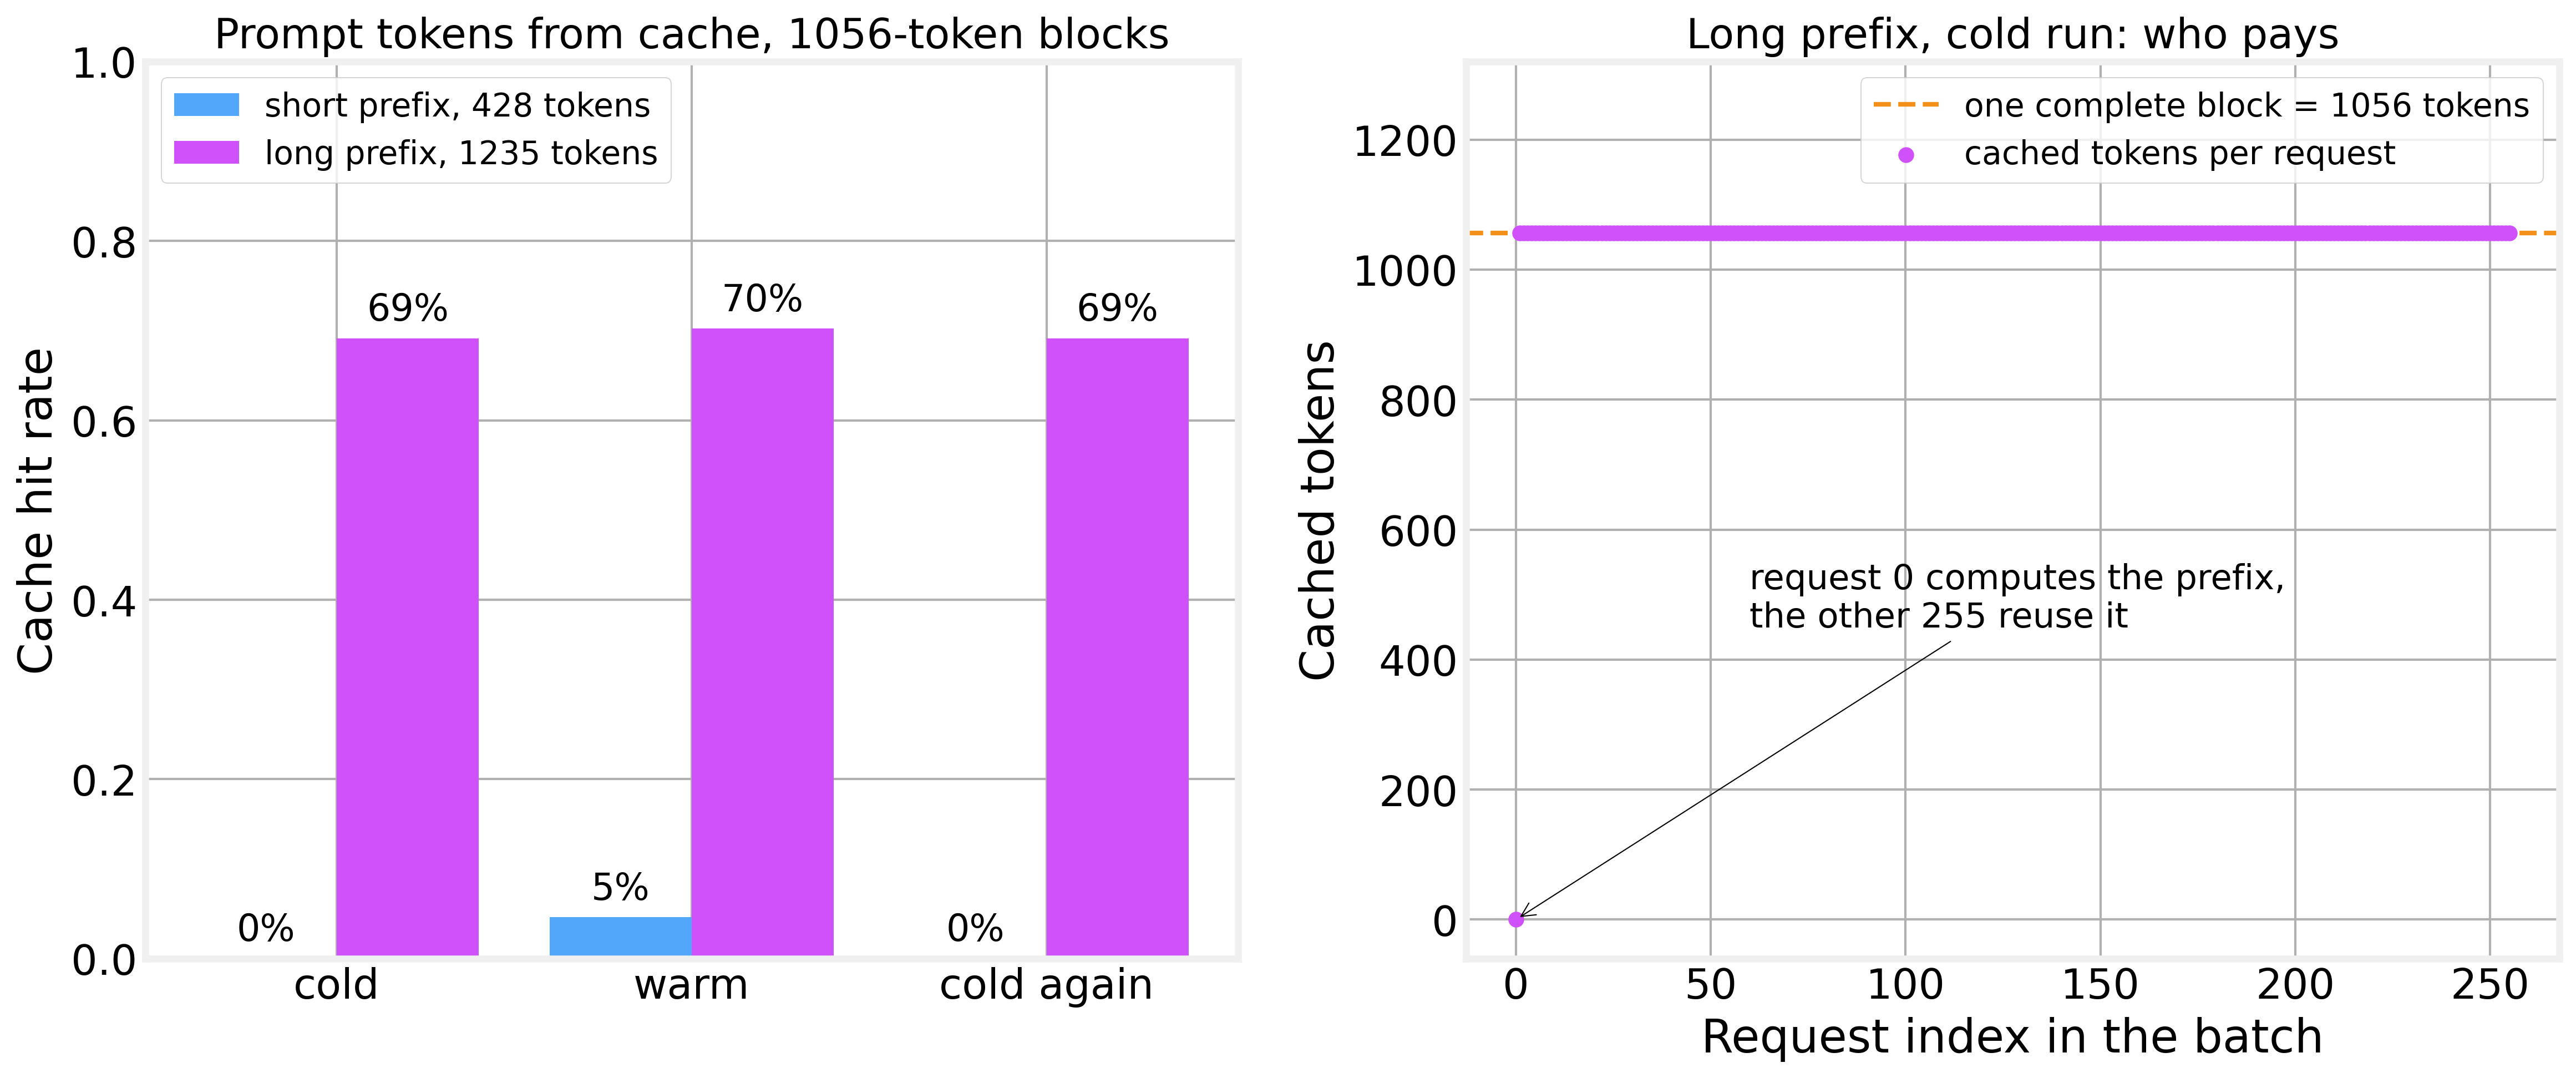

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# left: hit rate per run, short prefix next to long prefix
runs = cache_results["long"]["runs"].run
x = np.arange(len(runs))
for k, (name, offset) in enumerate([("short", -0.2), ("long", 0.2)]):
    rates = cache_results[name]["runs"].cache_hit_rate
    ax1.bar(x + offset, rates, width=0.4, color=colors[k],
            label=f"{name} prefix, {prefix_tokens[name]} tokens")
    for xi, v in zip(x + offset, rates):
        ax1.text(xi, v + 0.02, f"{v:.0%}", ha="center", fontsize=16)
ax1.set_xticks(x); ax1.set_xticklabels(runs)
ax1.set_ylim(0, 1)
ax1.set_ylabel("Cache hit rate")
ax1.set_title(f"Prompt tokens from cache, {block_size}-token blocks", fontsize=18)
ax1.legend(fontsize=14, loc="upper left")

# right: cached tokens per request, long prefix, cold run, in scheduling order
per_req = np.array(cache_results["long"]["per_request"]["cold"])
ax2.axhline(block_size, color=colors[3], linestyle="--", linewidth=2, zorder=1,
            label=f"one complete block = {block_size} tokens")
ax2.scatter(np.arange(len(per_req)), per_req, s=40, color=colors[1], zorder=2,
            label="cached tokens per request")
ax2.annotate(f"request 0 computes the prefix,\nthe other {len(per_req)-1} reuse it", xy=(0, per_req[0]),
             xytext=(60, 450), fontsize=15, arrowprops=dict(arrowstyle="->", color="black"))
ax2.set_ylim(-60, block_size * 1.25)
ax2.set_xlabel("Request index in the batch")
ax2.set_ylabel("Cached tokens")
ax2.set_title("Long prefix, cold run: who pays", fontsize=18)
ax2.legend(fontsize=14, loc="upper right")

for ax in (ax1, ax2):
    ax.tick_params(labelsize=18)
    ax.yaxis.label.set_size(20); ax.xaxis.label.set_size(20)


The two prefixes tell two different stories, and the block size is the whole difference between them.

With the **short prefix** nothing is shared: 0% of prompt tokens from cache cold, 5% warm, and only 8 of the 256 requests get any hit at all. The 5% is not sharing between requests. It is 8,448 tokens, exactly 8 x 1,056: the eight requests whose *whole prompt* exceeds one block, each getting its own first block back from the cold run of the very same request. A 428-token prefix never completes a block, so there is nothing for the other 255 requests to find.

With the **long prefix** the theory and the measurement agree. In the cold run 69% of all prompt tokens come from cache and exactly one request, the first one scheduled, pays full price: it computes the shared block and the other 255 find it already resident *in the same batch*. That is the right-hand panel, and it is the result most people do not expect: the engine does not need a previous call to benefit. The warm run adds only a little, because the cold run had already captured nearly everything there was to share.

Two further points. Only the first 1,056 of the 1,235 prefix tokens are shareable, so 179 tokens per request are recomputed that a model with 16-token blocks would have cached. And wall-clock time barely moves between runs, because at this batch size the work is dominated by decoding the answers rather than by prefill: the cache saves compute and memory bandwidth rather than seconds here, and it would save seconds in a single-user chat, where every turn repeats the whole conversation so far.

The general lesson is the one this notebook keeps returning to. Had we trusted the documentation instead of `num_cached_tokens`, the short-prefix experiment would have gone out claiming long system prompts were free on a model where, at that length, they were not. Every performance feature deserves one measurement before it is relied upon, and the measurement should print the quantity the feature is supposed to change, not just the stopwatch.


## 8. Structured outputs

Asking a model to "respond in JSON" is a request, not a guarantee. The model may wrap the object in Markdown fences, add a sentence of commentary, invent a field, or emit a string where you asked for a boolean. Downstream code then needs a parser, a validator, and a retry loop. We built exactly that defensive machinery in notebook 3.

vLLM offers something stronger: **grammar-constrained decoding**. Given a JSON schema, the engine compiles it into a grammar and, at every decode step, masks out every token that would make the output invalid. The model cannot produce a wrong shape because the wrong tokens are never available to sample. The pydantic model below is the single source of truth: its JSON schema constrains the model, and its validator checks the result.

The schema is the actual analytic question of this notebook. The corpus was retrieved by the phrase "scaling laws", and we want to know what *kind* of scaling each paper is about, whether it is empirical or theoretical, and whether it claims a power law.

In [19]:
class PaperExtraction(BaseModel):
    """What a 'scaling laws' paper is actually about."""
    scaling_domain: Literal[
        "machine_learning", "physics", "biology_ecology", "cities_society_economics",
        "engineering_materials", "earth_climate", "other", "not_about_scaling",
    ] = Field(description="The domain in which the scaling relationship lives.")
    quantity_scaled: str = Field(description="The dependent quantity, in the paper's own words. Short phrase.")
    scaled_against: str = Field(description="The independent variable it scales with. Short phrase.")
    is_empirical: bool = Field(description="True if the paper measures the relationship in data; false if purely theoretical or computational.")
    claims_power_law: bool = Field(description="True if the abstract states or tests a power-law form.")
    one_line_finding: str = Field(description="The main result in one sentence of at most 25 words.")

schema = PaperExtraction.model_json_schema()
print(json.dumps(schema, indent=2)[:900], "...")

{
  "description": "What a 'scaling laws' paper is actually about.",
  "properties": {
    "scaling_domain": {
      "description": "The domain in which the scaling relationship lives.",
      "enum": [
        "machine_learning",
        "physics",
        "biology_ecology",
        "cities_society_economics",
        "engineering_materials",
        "earth_climate",
        "other",
        "not_about_scaling"
      ],
      "title": "Scaling Domain",
      "type": "string"
    },
    "quantity_scaled": {
      "description": "The dependent quantity, in the paper's own words. Short phrase.",
      "title": "Quantity Scaled",
      "type": "string"
    },
    "scaled_against": {
      "description": "The independent variable it scales with. Short phrase.",
      "title": "Scaled Against",
      "type": "string"
    },
    "is_empirical": {
      "description": "True if the paper measure ...


### The unconstrained baseline

First the honest control: the same schema, described in the prompt, with the model free to write anything. We measure how often the output parses *and* validates. Deterministic decoding (`temperature=0`) makes this the model's best effort, not a sampling accident.

In [20]:
EXTRACT_SYSTEM = (
    "You extract structured information from scientific abstracts about scaling relationships. "
    "Respond with a single JSON object matching this schema, and nothing else:\n"
    + json.dumps(schema)
)

def extract_messages(row):
    return [{"role": "system", "content": EXTRACT_SYSTEM},
            {"role": "user", "content": f"Title: {row.title}\n\nAbstract: {row.abstract}"}]

def try_parse(text):
    """Return (PaperExtraction | None, failure_kind)."""
    try:
        obj = json.loads(text)
    except json.JSONDecodeError:
        return None, "invalid JSON"
    try:
        return PaperExtraction.model_validate(obj), None
    except ValidationError:
        return None, "schema violation"


PILOT_N = 200
pilot_convs = [extract_messages(r) for r in works.iloc[:PILOT_N].itertuples()]

free_sampling = SamplingParams(temperature=0.0, max_tokens=300, seed=SEED)
free_outs, free_s, free_gen = cached_batch("pilot_unconstrained", pilot_convs, free_sampling)
free_results = [try_parse(o.outputs[0].text) for o in free_outs]
free_failures = Counter(kind for _, kind in free_results if kind)

print(f"unconstrained: {free_s:.1f} s, {free_gen/free_s:.0f} tok/s")
print(f"  parsed + valid : {sum(r is not None for r, _ in free_results)}/{PILOT_N}")
print(f"  failures       : {dict(free_failures)}")
bad = next((o.outputs[0].text for o, (r, _) in zip(free_outs, free_results) if r is None), None)
if bad:
    print("\nexample failure:\n", bad[:400])

Loading cached pilot_unconstrained from outputs/vllm/cache/pilot_unconstrained__e06a623eb980.pkl
unconstrained: 62.5 s, 423 tok/s
  parsed + valid : 1/200
  failures       : {'schema violation': 194, 'invalid JSON': 5}

example failure:
 {
  "description": "A theoretical study of tunneling time scaling for Bose-condensed atoms across different energy regimes.",
  "properties": {
    "scaling_domain": "physics",
    "quantity_scaled": "tunneling time",
    "scaled_against": "incident velocity and energy",
    "is_empirical": false,
    "claims_power_law": false,
    "one_line_finding": "Tunneling time scales differently with incide


### The constrained run

Same prompts, same sampling, plus one field: `structured_outputs=StructuredOutputsParams(json=schema)`. Note that we keep the schema in the prompt as well. The grammar guarantees the *shape*; the prompt is what tells the model what the fields *mean*.

In [21]:
constrained_sampling = SamplingParams(
    temperature=0.0, max_tokens=300, seed=SEED,
    structured_outputs=StructuredOutputsParams(json=schema),
)

con_outs, con_s, con_gen = cached_batch("pilot_constrained", pilot_convs, constrained_sampling)
con_results = [try_parse(o.outputs[0].text) for o in con_outs]
con_failures = Counter(kind for _, kind in con_results if kind)

print(f"constrained  : {con_s:.1f} s, {con_gen/con_s:.0f} tok/s")
print(f"  parsed + valid : {sum(r is not None for r, _ in con_results)}/{PILOT_N}")
print(f"  failures       : {dict(con_failures) or 'none'}")
print()
print(json.dumps(con_results[0][0].model_dump(), indent=2))

Loading cached pilot_constrained from outputs/vllm/cache/pilot_constrained__7fc4a83b1ed0.pkl
constrained  : 47.2 s, 397 tok/s
  parsed + valid : 200/200
  failures       : none

{
  "scaling_domain": "physics",
  "quantity_scaled": "tunneling time",
  "scaled_against": "incident velocity and energy regimes",
  "is_empirical": false,
  "claims_power_law": false,
  "one_line_finding": "Tunneling time scales differently with incident velocity depending on energy regimes, decreasing rapidly for negative energy and peaking for positive energy below the barrier."
}


The constrained run validates on every row, and the throughput cost of the grammar is small: the mask is computed on the CPU in parallel with the GPU's forward pass, so it only shows up when the grammar is complex or the batch is tiny. Compare that with the baseline's failure rate, and remember that every one of those failures would have been a retry (double the cost) or a silently dropped row.

Now the real run: every abstract in the sample.

In [ ]:
all_convs = [extract_messages(r) for r in works.itertuples()]
all_outs, all_s, all_gen = cached_batch("extraction", all_convs, constrained_sampling)

records = []
for row, o in zip(works.itertuples(), all_outs):
    parsed, kind = try_parse(o.outputs[0].text)
    rec = parsed.model_dump() if parsed else {"scaling_domain": None}
    rec.update(id=row.id, year=row.year, openalex_domain=row.domain, openalex_field=row.field,
               finish_reason=o.outputs[0].finish_reason, gen_tokens=len(o.outputs[0].token_ids))
    records.append(rec)
extracted = pd.DataFrame(records)

prompt_total = sum(len(o.prompt_token_ids) for o in all_outs)
print(f"{len(works):,} abstracts in {all_s/60:.1f} min")
print(f"  prompt tokens    : {prompt_total:,}  ({prompt_total/all_s:,.0f} tok/s)")
print(f"  generated tokens : {all_gen:,}  ({all_gen/all_s:,.0f} tok/s)")
print(f"  valid records    : {extracted.scaling_domain.notna().sum():,}")
print(f"  finish reasons   : {dict(extracted.finish_reason.value_counts())}")
extracted.to_json(OUTPUT_DIR / "extractions.jsonl", orient="records", lines=True)

Loading cached extraction from outputs/vllm/cache/extraction__4a206d095b52.pkl
1,982 abstracts in 8.0 min
  prompt tokens    : 1,354,498  (2,820 tok/s)
  generated tokens : 184,643  (384 tok/s)
  valid records    : 1,982
  finish reasons   : {'stop': np.int64(1982)}


## 9. What the model found

We now have a structured record for every abstract, which turns a language-model exercise into an ordinary data analysis. The first question is the one the corpus poses: a search for "scaling laws" pulls papers from every field. **Which fields, in what proportion, and has that mix changed?**

scaling_domain
physics                     0.421
engineering_materials       0.332
earth_climate               0.080
biology_ecology             0.058
machine_learning            0.046
cities_society_economics    0.038
other                       0.020
not_about_scaling           0.003
Name: proportion, dtype: float64

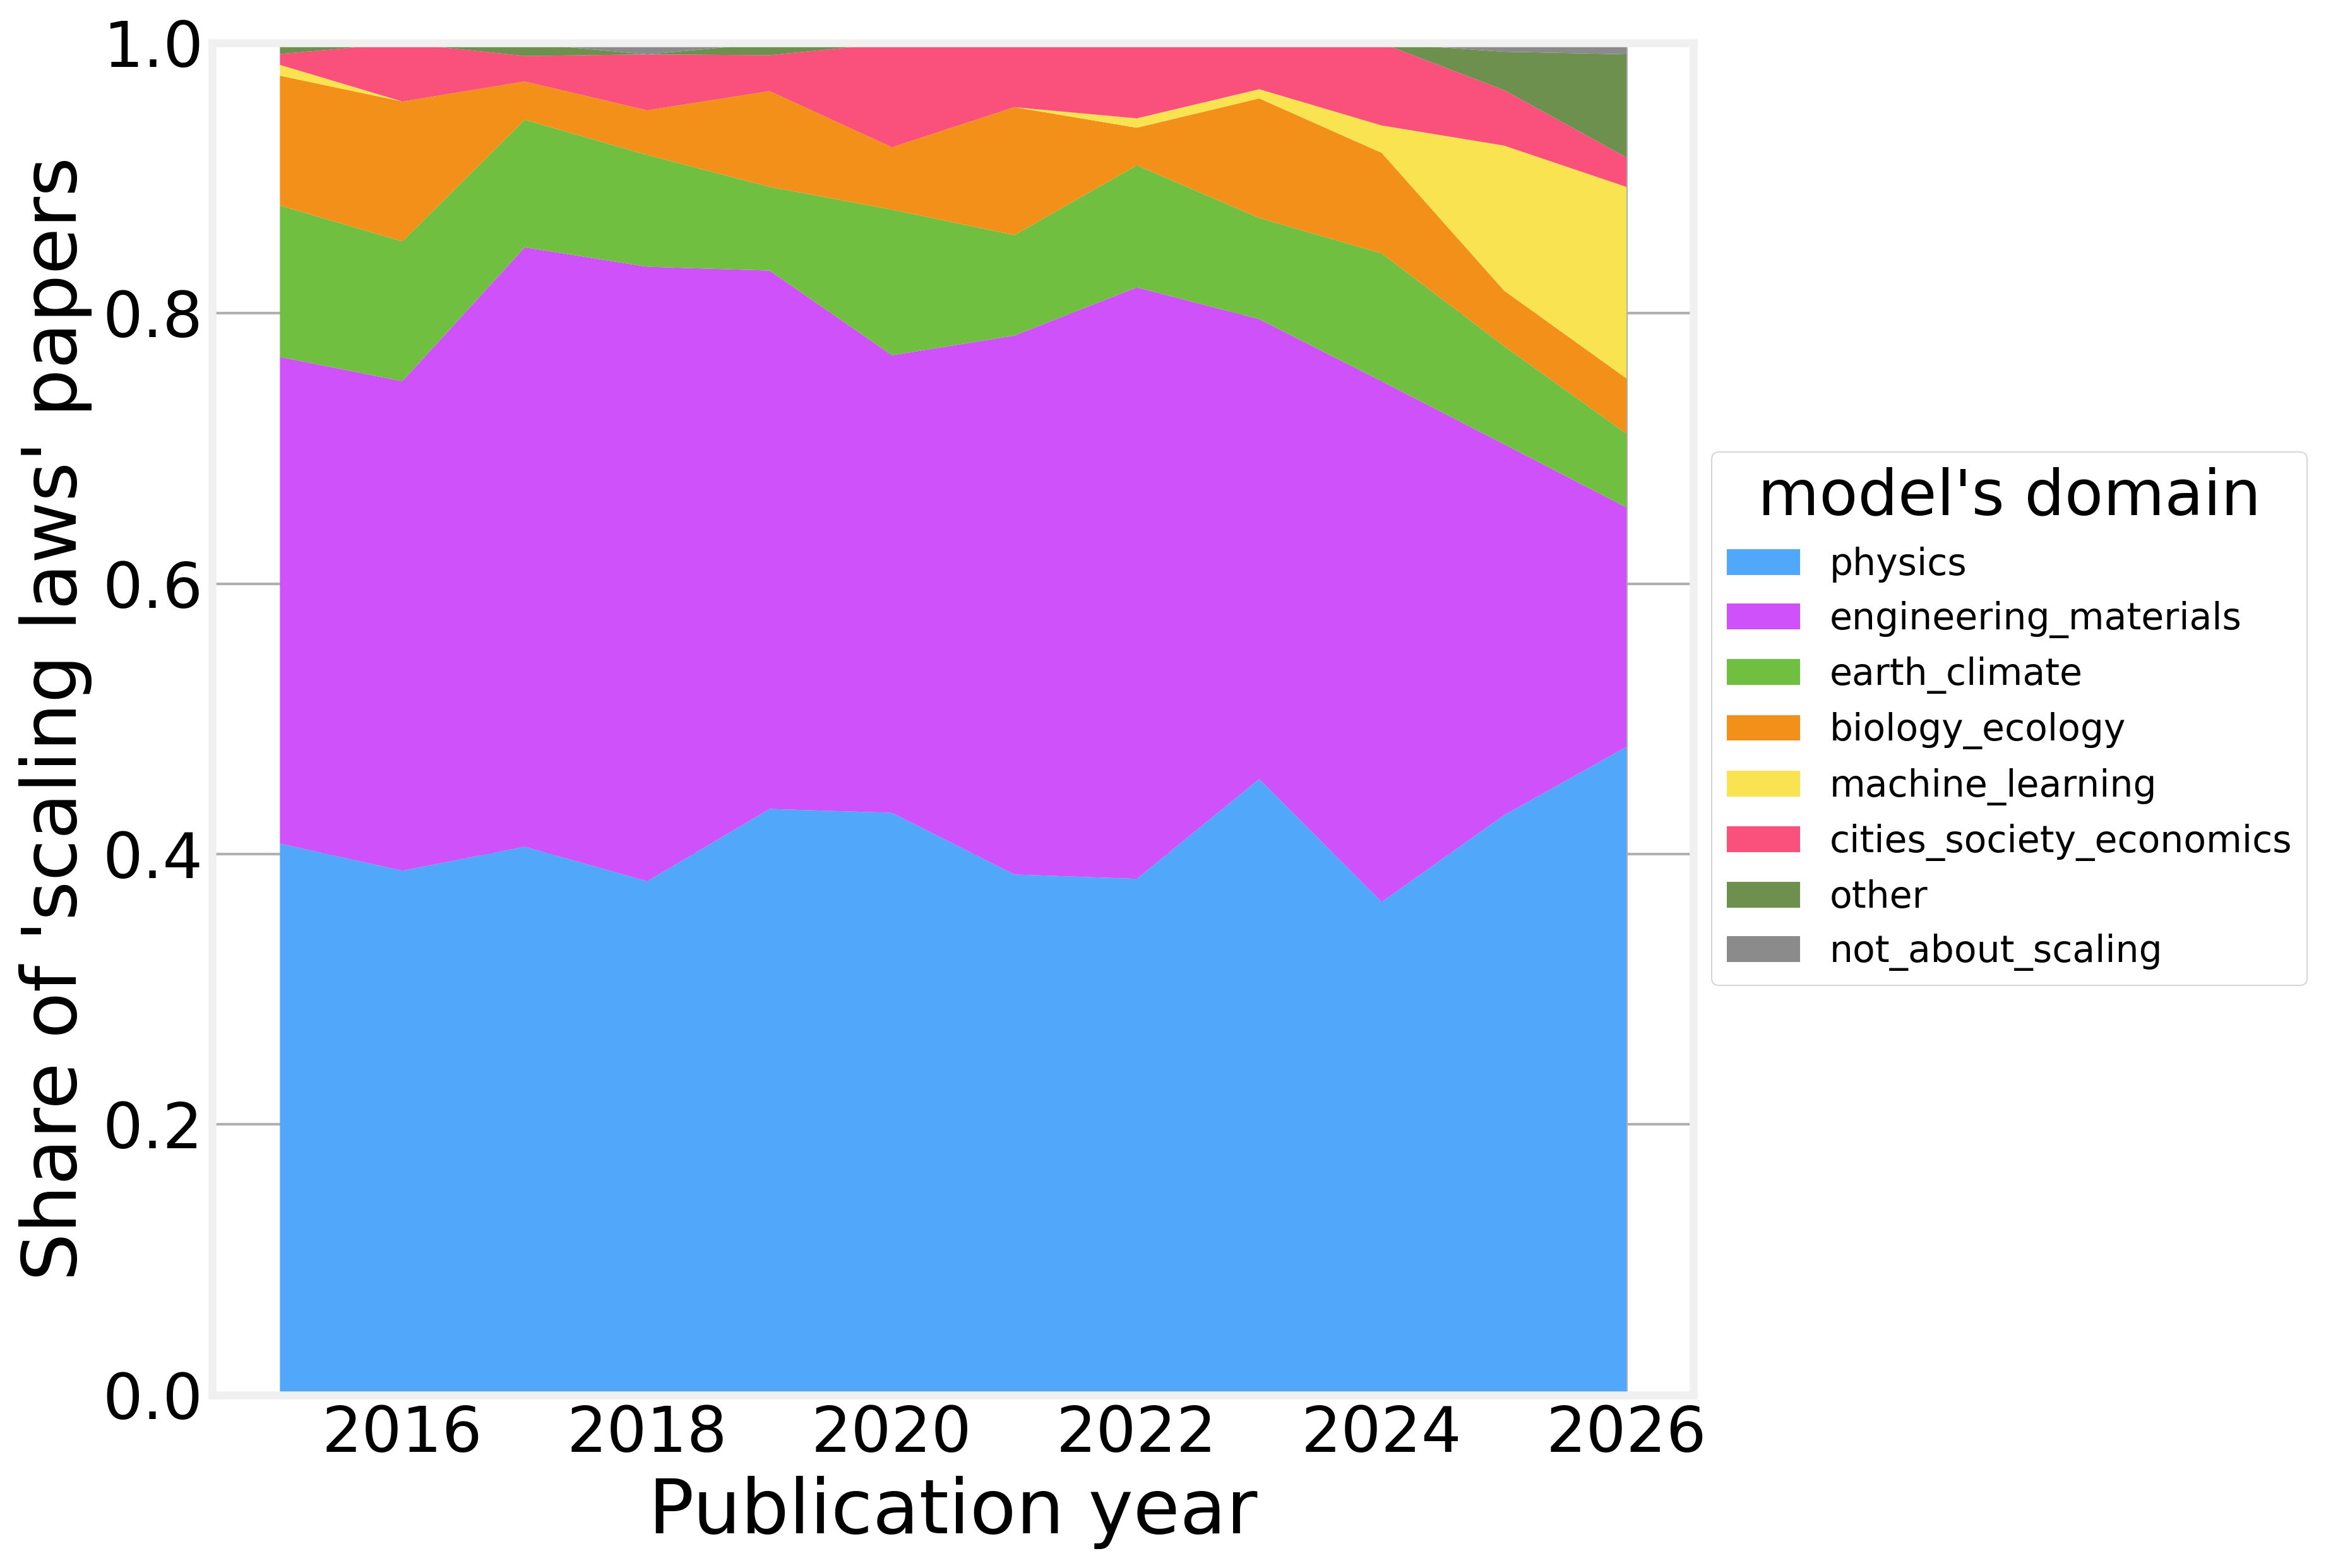

In [ ]:
domain_order = (extracted.scaling_domain.value_counts().index.tolist())
by_year = (extracted.groupby(["year", "scaling_domain"]).size()
           .unstack(fill_value=0).reindex(columns=domain_order))
share = by_year.div(by_year.sum(axis=1), axis=0)

fig, ax = plt.subplots()
share.plot.area(ax=ax, color=colors[:len(domain_order)], linewidth=0)
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of 'scaling laws' papers")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=14, title="model's domain")

extracted.scaling_domain.value_counts(normalize=True).round(3)

The second question is the sceptical one. OpenAlex assigns every work a domain through its own classifier. **Does the model's reading of the abstract agree with it?** Where they disagree systematically, one of them has a blind spot, and the cross-tabulation tells us where to look.

scaling_domain,physics,engineering_materials,earth_climate,biology_ecology,machine_learning,cities_society_economics,other,not_about_scaling
openalex_domain,,,,,,,,
Health Sciences,15,7,0,10,7,0,2,0
Life Sciences,24,11,3,53,2,0,0,0
Physical Sciences,790,636,153,45,74,35,35,2
Social Sciences,6,5,3,7,9,41,3,4


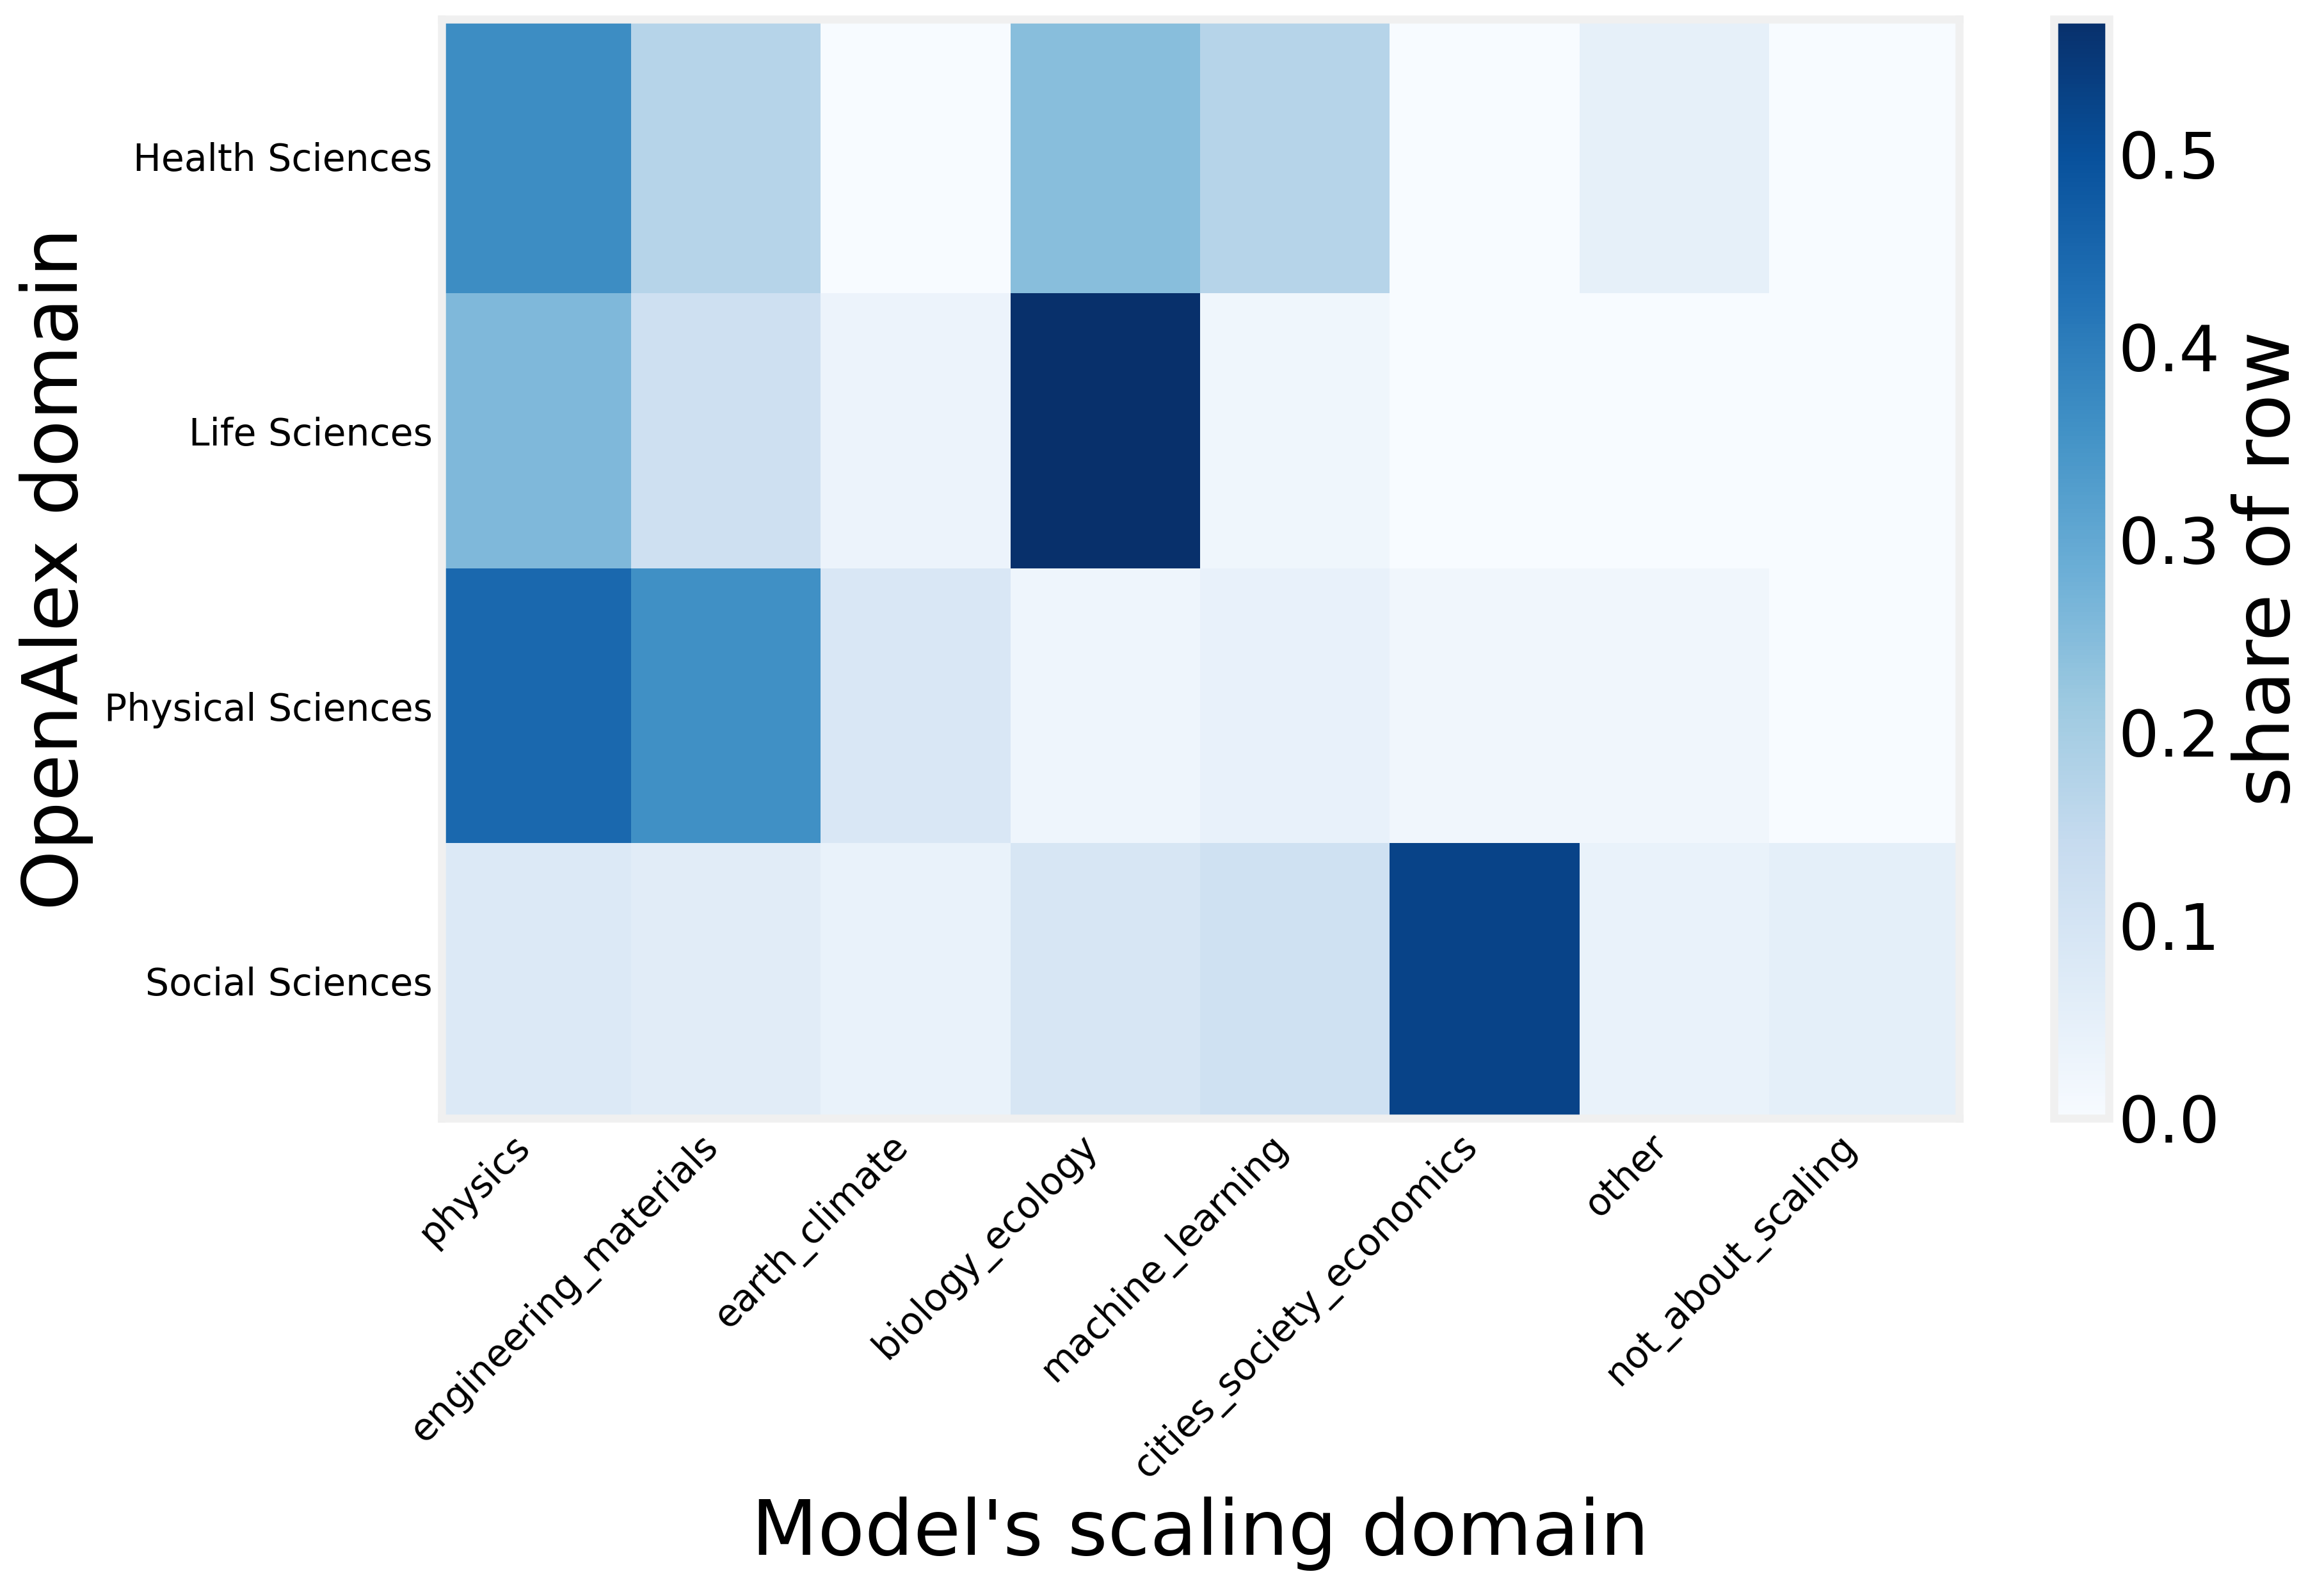

In [ ]:
agreement = pd.crosstab(extracted.openalex_domain, extracted.scaling_domain)
agreement = agreement.reindex(columns=domain_order)

fig, ax = plt.subplots()
im = ax.imshow(agreement.div(agreement.sum(axis=1), axis=0).values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(agreement.columns)))
ax.set_xticklabels(agreement.columns, rotation=45, ha="right", fontsize=14)
ax.set_yticks(range(len(agreement.index)))
ax.set_yticklabels(agreement.index, fontsize=14)
ax.set_xlabel("Model's scaling domain")
ax.set_ylabel("OpenAlex domain")
ax.grid(False)
fig.colorbar(im, ax=ax, label="share of row")

agreement

Finally, the question only the extraction can answer, because no metadata field holds it: **how often is a "scaling law" actually a power law, and is it measured or derived?**

,papers,power_law,empirical
scaling_domain,,,
physics,835,0.61,0.38
engineering_materials,659,0.44,0.59
earth_climate,159,0.62,0.64
biology_ecology,115,0.76,0.67
machine_learning,92,0.53,0.73
cities_society_economics,76,0.83,0.86
other,40,0.42,0.25


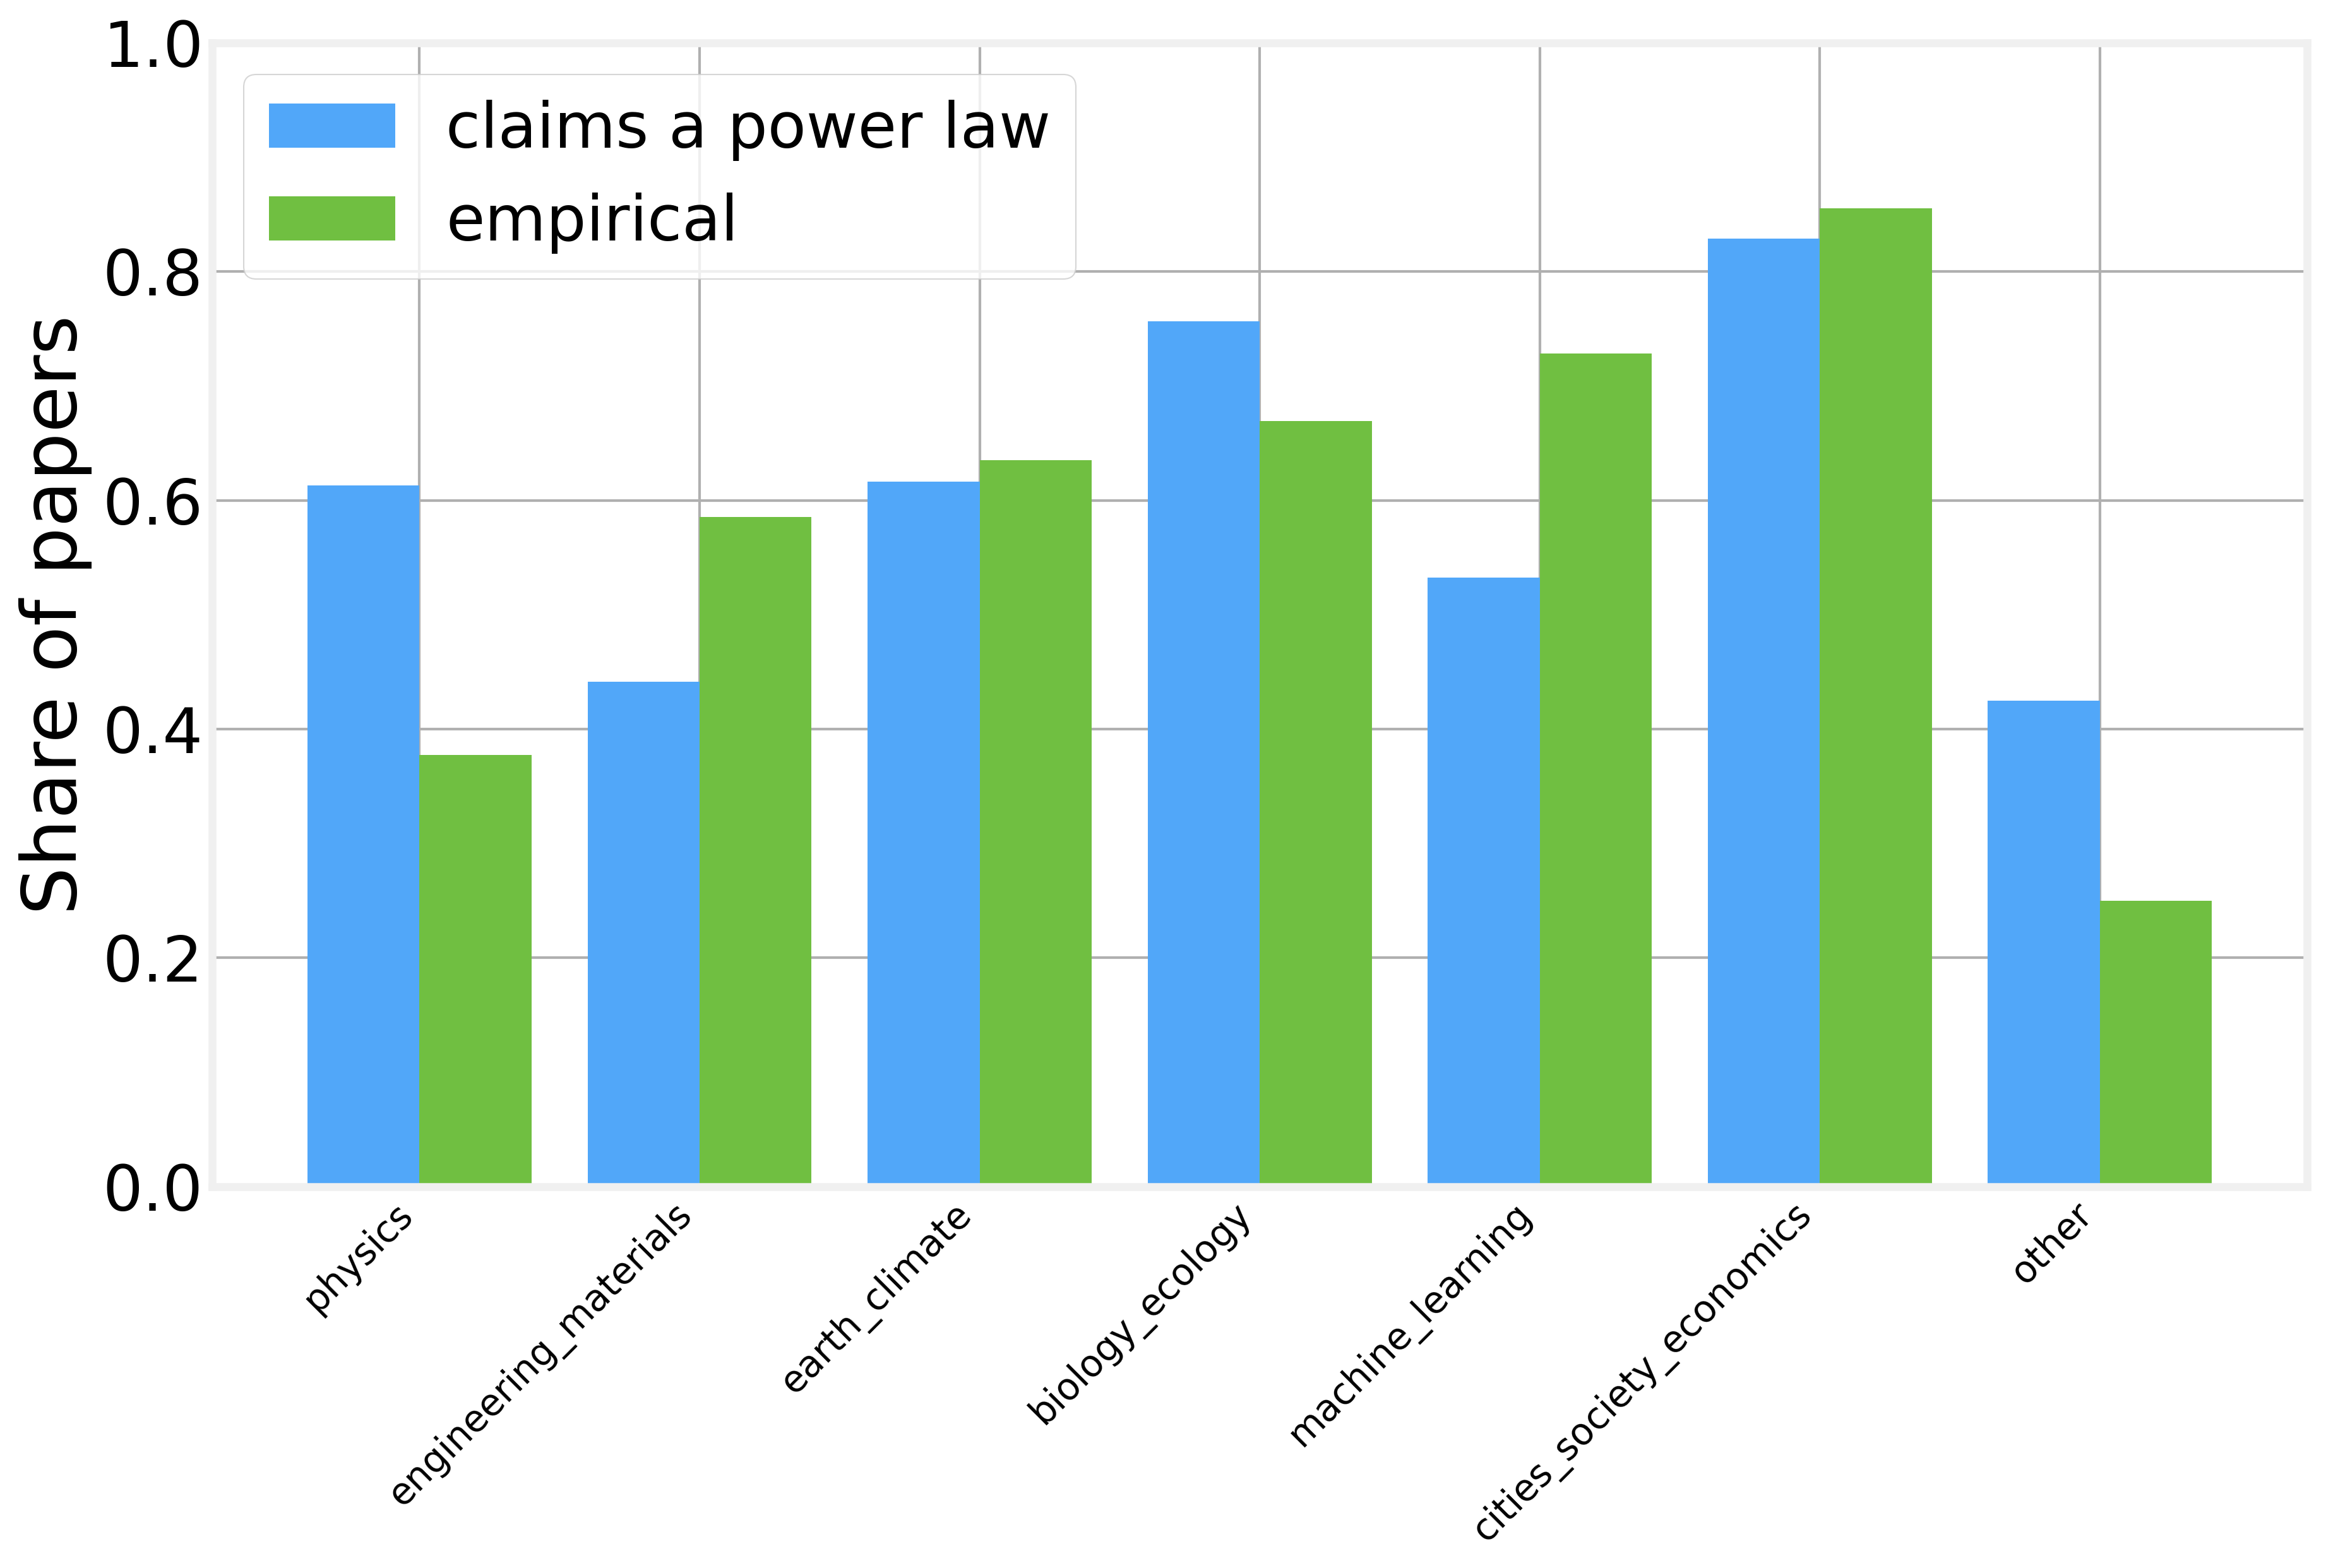

In [ ]:
valid = extracted.dropna(subset=["scaling_domain"])
valid = valid[valid.scaling_domain != "not_about_scaling"]

summary = (valid.groupby("scaling_domain")
           .agg(papers=("id", "size"),
                power_law=("claims_power_law", "mean"),
                empirical=("is_empirical", "mean"))
           .sort_values("papers", ascending=False))

fig, ax = plt.subplots()
x = np.arange(len(summary))
ax.bar(x - 0.2, summary.power_law, width=0.4, color=colors[0], label="claims a power law")
ax.bar(x + 0.2, summary.empirical, width=0.4, color=colors[2], label="empirical")
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=45, ha="right", fontsize=14)
ax.set_ylabel("Share of papers")
ax.set_ylim(0, 1)
ax.legend()

summary.round(2)

A few extracted records, to keep the aggregate honest. Reading ten of these against their abstracts is the cheapest evaluation you will ever run, and it is where you discover whether `quantity_scaled` is a *quantity* or a restatement of the title.

In [26]:
sample_cols = ["scaling_domain", "quantity_scaled", "scaled_against", "claims_power_law", "one_line_finding"]
with pd.option_context("display.max_colwidth", 80):
    display(valid.sample(8, random_state=SEED)[sample_cols])

,scaling_domain,quantity_scaled,scaled_against,claims_power_law,one_line_finding
1832,engineering_materials,creep amplitude,applied stress and hydrogel concentration,True,Creep amplitude scales exponentially with applied stress and hydrogel concen...
1742,earth_climate,chimney depth and radius,time and buoyancy loss,False,"Analytical solutions describe chimney depth and radius evolution, agreeing w..."
679,engineering_materials,Q factor,ratio of antenna particles to all particles,False,The Q factor exhibits two scaling regimes with saturated and unsaturated res...
351,engineering_materials,quality factor (Q factor),number of rings,True,The Q factor scales with the fifth power of the number of rings in degenerat...
1734,engineering_materials,optoelectrical performance (sheet resistance),co-percolation of carbon nanotubes in silver nanowire networks,True,Adding carbon nanotubes to silver nanowire networks near the percolation thr...
610,physics,relaxation times,radius of gyration,True,"Bottlebrush relaxation times scale with radius of gyration as tau ~ Rg^3.4, ..."
70,engineering_materials,helical instability characteristics,viscous and centripetal forces,False,"A force balance scaling law predicts helical instability in film blowing, ma..."
1126,machine_learning,discovery-efficiency and adversarial robustness,traditional Scaling Law-based models,False,The paper proposes an 'Inference Laws' paradigm that outperforms traditional...


## 10. From notebook to server

Everything above ran inside one Python process. In production the same engine runs behind an **OpenAI-compatible HTTP server**, and every flag we chose maps one to one onto a command-line argument:

```bash
vllm serve Qwen/Qwen3.5-35B-A3B-FP8 \
    --max-model-len 4096 \
    --max-num-seqs 256 \
    --gpu-memory-utilization 0.50 \
    --limit-mm-per-prompt '{"image": 0, "video": 0}' \
    --default-chat-template-kwargs '{"enable_thinking": false}' \
    --port 8000
```

The server speaks the Chat Completions protocol, so any OpenAI client works unchanged; structured outputs arrive through the standard `response_format` field, and prefix caching and continuous batching happen on the server side exactly as they did here, now across concurrent *clients*:

```python
from openai import OpenAI

client = OpenAI(base_url="http://localhost:8000/v1", api_key="unused")
response = client.chat.completions.create(
    model="Qwen/Qwen3.5-35B-A3B-FP8",
    messages=extract_messages(works.iloc[0]),
    temperature=0,
    response_format={"type": "json_schema",
                     "json_schema": {"name": "PaperExtraction", "schema": schema}},
)
PaperExtraction.model_validate_json(response.choices[0].message.content)
```

This is also the bridge back to the rest of the series. The provider abstraction from notebook 1 has a single `complete(system, user)` method. A `LocalProvider` that points an OpenAI client at `localhost:8000` is a dozen lines, and the harness of notebooks 3 and 4 runs on your own hardware with no other change. Run the evaluation suite of notebook 4 against it and you have a *measured* answer to the question every team eventually asks: how much capability do we give up by going local, and is it worth what we gain?

## 11. Where to go from here

* **Speculative decoding.** Qwen3.5 ships a multi-token-prediction (MTP) head, and vLLM can use it to draft several tokens per step and verify them in one forward pass. For a bandwidth-bound single stream this is the most direct way to beat the ceiling in Section 1. Try `spec_method="mtp"` with a small number of speculative tokens and re-run the batch-size sweep: the gain is largest at small batches and shrinks as batching already fills the hardware.
* **FP8 KV cache.** We quantized the weights, not the cache. `kv_cache_dtype="fp8"` halves the per-token cost from Section 2 again, at the price of a small, measurable quality change. Measure it with the agreement matrix of Section 9.
* **Run a control.** Two results here depend on this model's hybrid architecture as much as on the engine: the KV cache capacity and the block-size condition on prefix caching. Repeat Sections 6 and 7 on a model with conventional attention in every layer and a 16-token KV block, and compare the curves side by side; the shape of the batching curve, not just its height, may differ.
* **Sort the workload.** Section 7 showed that cache hits depend on block alignment and scheduling order. Group requests by shared prefix, keep the shared part at the front, and for multi-turn agents keep the conversation history as a stable prefix with new material appended at the end. On a hybrid model, also check whether a smaller `block_size` is accepted and what it costs.
* **Multimodal input.** We switched off the vision tower to save memory. Switch it back on and the same engine reads figures: the obvious extension is extracting the exponent from a paper's log-log plot rather than from its abstract.
* **Benchmark properly.** `vllm bench serve` drives the server with a controlled request rate and reports time-to-first-token and inter-token latency distributions, which are what users feel. Throughput, which is what we measured, is what the bill feels.
* **Evaluate the extraction.** Hand-label a hundred abstracts and compute precision and recall for `scaling_domain` and `claims_power_law`. Notebook 4 has the machinery. Until then, the figures in Section 9 are the model's opinion, carefully structured.

<center>
<img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" width="300px">
</center>